Notebook for producing the paper plots.

In [83]:
import pandas as pd
import numpy as np
import pickle
import obspy
import ast
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import scipy.cluster.hierarchy as sch
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    extract_split_flows,
    find_date_in_strings,
)
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.metrics import find_fp_fn
from seismicif.datamod.loading_utils import (
    limit_segment_length,
    preproc_flow_annotations,
    find_paths,
    find_date_in_strings,
    sliding_windows_from_trace,
)

from datetime import timedelta
from seismicif.isolation_forest import create_if_stream
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform, pdist
from seismicif.sta_lta import create_slta_trace
from matplotlib.ticker import ScalarFormatter
from sklearn.tree import plot_tree
from matplotlib.patches import ConnectionPatch
from fastdtw import fastdtw
from seismicif.dtw import segment_dtw
from joblib import load
from dynamicTreeCut import cutreeHybrid
from seismicif.metrics import iou

plt.rcParams["font.family"] = "sans-serif"
ill_stations = ["ILL11", "ILL12", "ILL13", "ILL14", "ILL15", "ILL16", "ILL17", "ILL18"]
dk_stations = ["KARAT", "KARAT_CONT", "NUUG", "NUUG_CONT"]


def cluster_info(cluster):
    size = len(cluster)

    mapping = {"CAL": "MM", "ID": "MM", "TEQ": "EQ", "REQ": "EQ"}

    cluster["label"] = cluster["label"].replace(mapping)

    return cluster["label"].value_counts(dropna=False) / size

### iTree Illustration

In [ ]:
# read ILL18 IF model and extract tree built on 2018-05-27
paths = find_paths("XP", "ILL18", "EHZ.D", start=2018, stop=2019)
if_mod = load(f"../output/XP/if/models/ILL18.joblib")
est = if_mod.estimators_[5]
tree = est.tree_

# read example time windows
st = obspy.read(find_date_in_strings(paths, "2019-06-13")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z")
t1 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z") + timedelta(seconds=99.99)
x1 = st.trim(t0, t1)[0].data.reshape(1, -1)


st = obspy.read(find_date_in_strings(paths, "2019-06-20")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2019-06-20T09:09:37.370000Z")
t1 = obspy.UTCDateTime("2019-06-20T09:09:37.370000Z") + timedelta(seconds=99.99)
x2 = st.trim(t0, t1)[0].data.reshape(1, -1)

st = obspy.read(find_date_in_strings(paths, "2018-06-11")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2018-06-11T11:00:03.740003Z")
t1 = obspy.UTCDateTime("2018-06-11T11:00:03.740003Z") + timedelta(seconds=99.99)
x3 = st.trim(t0, t1)[0].data.reshape(1, -1)

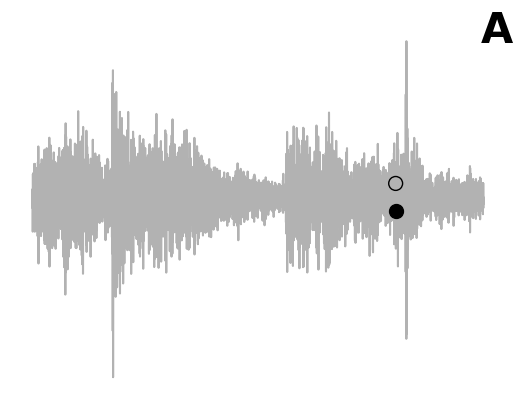

In [28]:
# plot first debris flow time window
symbol_size = 100
plt.plot(x2[0, :], c="k", alpha=0.3)

plt.scatter(
    tree.feature[0],
    tree.threshold[0] - 500,
    color="k",
    zorder=3,
    marker="o",
    s=symbol_size,
)
plt.scatter(
    tree.feature[0],
    x2[0, tree.feature[0]] + 150,
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
    s=symbol_size,
)


ax = plt.gca()
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])
ax.spines["left"].set_visible(False)
ax.yaxis.set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.set_title("Debris flow time window")

plt.text(0.95, 0.95, "A", transform=plt.gca().transAxes, fontsize=30, fontweight="bold")


plt.savefig("../plots/tree_flow_example1.pdf", dpi=300)

plt.show()

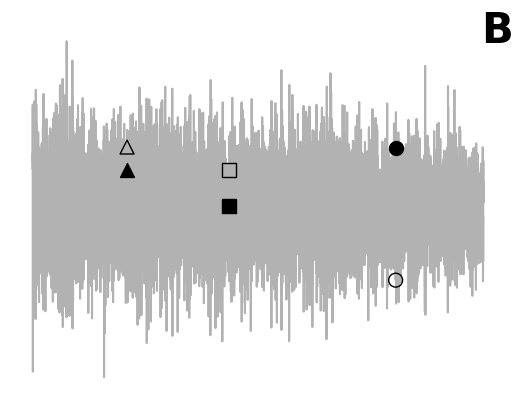

In [34]:
# plot second debris flow time window
plt.plot(x3[0, :], c="k", alpha=0.3)

# split markers
plt.scatter(tree.feature[0], tree.threshold[0], color="k", zorder=3, s=symbol_size)
plt.scatter(
    tree.feature[0],
    x3[0, tree.feature[0]],
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[1],
    tree.threshold[1] - 10,
    color="k",
    marker="s",
    zorder=3,
    s=symbol_size,
)
plt.scatter(
    tree.feature[1],
    x3[0, tree.feature[1]] + 10,
    color="k",
    zorder=3,
    marker="s",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[41], tree.threshold[41], color="k", marker="^", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[41],
    x3[0, tree.feature[41]],
    color="k",
    zorder=3,
    marker="^",
    facecolors="none",
    s=symbol_size,
)

ax = plt.gca()
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])
ax.spines["left"].set_visible(False)
ax.yaxis.set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.text(0.95, 0.95, "B", transform=plt.gca().transAxes, fontsize=30, fontweight="bold")

plt.savefig("../plots/tree_flow_example2.pdf", dpi=300)
plt.show()

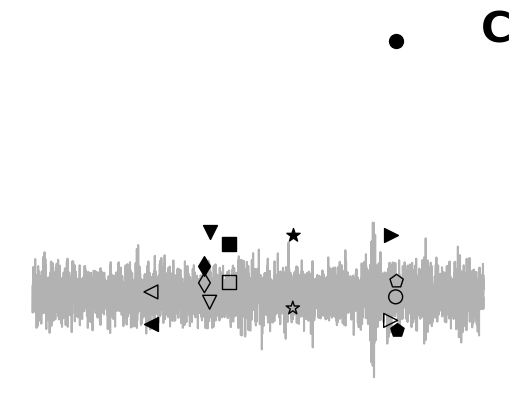

In [30]:
# plot second debris flow time window
plt.plot(x1[0, :], c="k", alpha=0.3)

plt.scatter(tree.feature[0], tree.threshold[0], color="k", zorder=3, s=symbol_size)
plt.scatter(
    tree.feature[0],
    x1[0, tree.feature[0]] - 2,
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[1], tree.threshold[1], color="k", marker="s", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[1],
    x1[0, tree.feature[1]],
    color="k",
    zorder=3,
    marker="s",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[2], tree.threshold[2], color="k", marker="v", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[2],
    x1[0, tree.feature[2]],
    color="k",
    zorder=3,
    marker="v",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[3], tree.threshold[3], color="k", marker="d", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[3],
    x1[0, tree.feature[3]],
    color="k",
    zorder=3,
    marker="d",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[4], tree.threshold[4], color="k", marker="*", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[4],
    x1[0, tree.feature[4]],
    color="k",
    zorder=3,
    marker="*",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[5], tree.threshold[5], color="k", marker="<", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[5],
    x1[0, tree.feature[5]],
    color="k",
    zorder=3,
    marker="<",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[11], tree.threshold[11], color="k", marker=">", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[11],
    x1[0, tree.feature[11]],
    color="k",
    zorder=3,
    marker=">",
    facecolors="none",
    s=symbol_size,
)
plt.scatter(
    tree.feature[12], tree.threshold[12], color="k", marker="p", zorder=3, s=symbol_size
)
plt.scatter(
    tree.feature[12],
    x1[0, tree.feature[12]] + 2,
    color="k",
    zorder=3,
    marker="p",
    facecolors="none",
    s=symbol_size,
)

ax = plt.gca()
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])
ax.spines["left"].set_visible(False)
ax.yaxis.set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.set_title("Normal time window")

plt.text(0.95, 0.95, "C", transform=plt.gca().transAxes, fontsize=30, fontweight="bold")

plt.savefig("../plots/tree_flow_example3.pdf", dpi=300)
plt.show()

### Rule of Thumb Thresholds

In [10]:
# collect all the IF anomaly scores
if_scores = []

for station in ill_stations:
    if_scores.append(
        pd.read_csv(f"../output/XP/if/scores/{station}.csv")["anomaly_score"].values
    )

for station in dk_stations:
    if_scores.append(
        pd.read_csv(f"../output/DK/if/scores/{station}.csv")["anomaly_score"].values
    )

if_scores = np.concatenate(if_scores)

In [16]:
print(
    np.round(100 * np.mean(if_scores >= 0.5), 2),
    np.round(100 * np.mean(if_scores >= 0.55), 2),
    np.round(100 * np.mean(if_scores >= 0.6), 2),
)

11.42 5.05 2.24


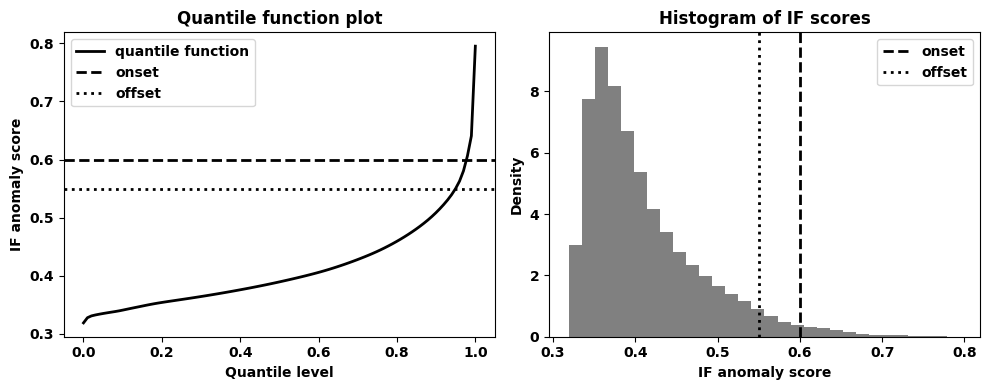

In [7]:
qlevels = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: Quantile function plot ---
axes[0].plot(
    qlevels,
    np.quantile(if_scores, qlevels),
    c="k",
    linewidth=2,
    label="quantile function",
)
axes[0].set_xlabel("Quantile level", fontweight="bold")
axes[0].set_ylabel("IF anomaly score", fontweight="bold")
axes[0].set_title("Quantile function plot", fontweight="bold")

axes[0].axhline(y=0.6, color="k", linestyle="dashed", label="onset", linewidth=2)
axes[0].axhline(y=0.55, color="k", linestyle="dotted", label="offset", linewidth=2)
axes[0].legend(prop={"weight": "bold"})

# --- Right: Histogram ---
axes[1].hist(if_scores, bins=30, density=True, color="gray")
axes[1].set_xlabel("IF anomaly score", fontweight="bold")
axes[1].set_ylabel("Density", fontweight="bold")
axes[1].set_title("Histogram of IF scores", fontweight="bold")

axes[1].axvline(x=0.6, linestyle="dashed", c="k", label="onset", linewidth=2)
axes[1].axvline(x=0.55, linestyle="dotted", c="k", label="offset", linewidth=2)
axes[1].legend(prop={"weight": "bold"})

# --- Bold tick labels on both plots ---
for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("../plots/rot.pdf", dpi=300)
plt.show()

### Greenland Table

In [35]:
station = "KARAT"
network = "DK"
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)
segments = segments[segments["scores"] >= 0.7].reset_index(drop=True)
segments = segments[segments["label"] != "N"].reset_index(drop=True)
segments = segments[segments["label"] != "TEQ"].reset_index(drop=True)
segments[["most_anomalous_start", "scores", "label"]]

,most_anomalous_start,scores,label
0,2022-10-10T03:10:45.350000Z,0.726770,CAL
1,2023-08-03T00:25:50.000000Z,0.723054,ID
2,2023-08-25T12:41:40.000000Z,0.720424,CAL
3,2023-07-27T07:00:00.000000Z,0.720379,CAL
4,2023-07-03T09:34:52.320000Z,0.719906,CAL
5,2022-12-27T03:01:40.000000Z,0.715773,CAL
6,2023-04-11T11:37:22.320000Z,0.704491,CAL
7,2022-10-17T09:29:55.350000Z,0.703665,CAL
8,2023-10-02T15:01:49.415000Z,0.701096,CAL
9,2023-08-21T09:53:20.000000Z,0.700739,CAL


### ILL11 and ILL14 IF Scores vs log stdev plots

In [3]:
flows = pd.read_csv("../catalogs/XP/flow_catalog.csv")
mask = flows["start"].astype(str).str.contains("2018")
flows = flows.loc[mask].reset_index(drop=True)
flows = preproc_flow_annotations(flows)

In [ ]:
scores_ILL11 = pd.read_csv(f"../output/XP/if/scores/ILL11.csv", index_col=0)
scores_ILL14 = pd.read_csv(f"../output/XP/if/scores/ILL14.csv", index_col=0)

mask = scores_ILL11["start"].astype(str).str.contains("2018")
scores_ILL11 = scores_ILL11.loc[mask].reset_index(drop=True)
mask = scores_ILL14["start"].astype(str).str.contains("2018")
scores_ILL14 = scores_ILL14.loc[mask].reset_index(drop=True)

scores_ILL11["start"] = [obspy.UTCDateTime(i) for i in scores_ILL11["start"]]
scores_ILL11["stop"] = [obspy.UTCDateTime(i) for i in scores_ILL11["stop"]]
scores_ILL14["start"] = [obspy.UTCDateTime(i) for i in scores_ILL14["start"]]
scores_ILL14["stop"] = [obspy.UTCDateTime(i) for i in scores_ILL14["stop"]]

scores_ILL11["label"] = np.zeros(len(scores_ILL11), dtype=int)
scores_ILL14["label"] = np.zeros(len(scores_ILL14), dtype=int)

station_flows = flows[flows["station"] == "ILL11"].copy().reset_index(drop=True)

for i in range(len(station_flows)):
    catalog_segment = station_flows.loc[i]
    start = catalog_segment["start"]
    stop = catalog_segment["stop"]
    idx = np.where((scores_ILL11["start"] > start) & (scores_ILL11["start"] < stop))[0]

    if catalog_segment["confidence"] == "low":
        scores_ILL11.loc[idx, "label"] = 1

    elif catalog_segment["confidence"] == "med":
        scores_ILL11.loc[idx, "label"] = 2

    elif catalog_segment["confidence"] == "high":
        scores_ILL11.loc[idx, "label"] = 3

station_flows = flows[flows["station"] == "ILL14"].copy().reset_index(drop=True)

for i in range(len(station_flows)):
    catalog_segment = station_flows.loc[i]
    start = catalog_segment["start"]
    stop = catalog_segment["stop"]
    idx = np.where((scores_ILL14["start"] > start) & (scores_ILL14["start"] < stop))[0]

    if catalog_segment["confidence"] == "low":
        scores_ILL14.loc[idx, "label"] = 1

    elif catalog_segment["confidence"] == "med":
        scores_ILL14.loc[idx, "label"] = 2

    elif catalog_segment["confidence"] == "high":
        scores_ILL14.loc[idx, "label"] = 3

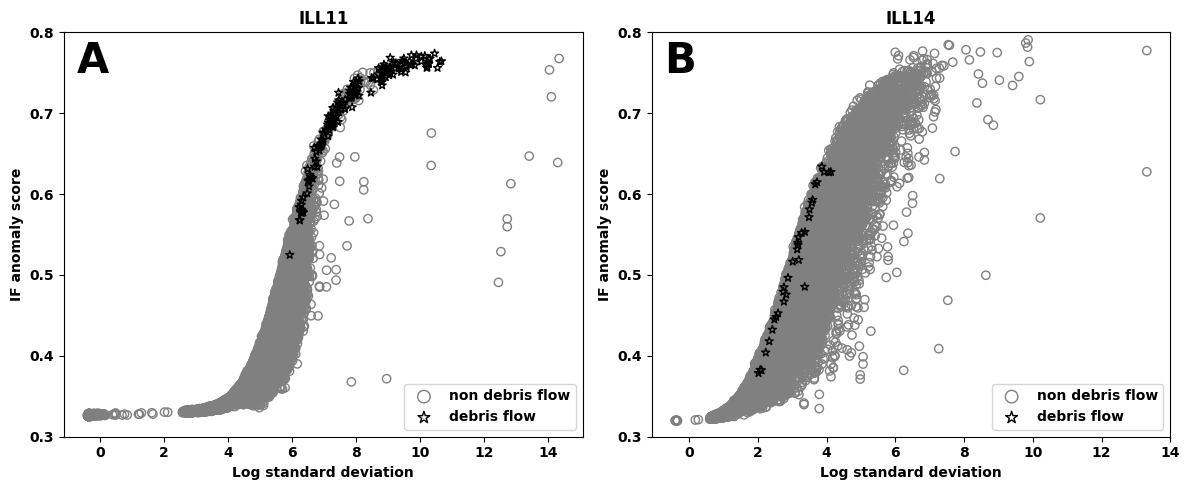

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labs1 = scores_ILL11["label"]
labs2 = scores_ILL14["label"]

markesrs = ["o", "s", "d", "*"]
colors = ["gray", "k", "k", "k"]
label = ["non debris flow", "low confidence", "med confidence", "debris flow"]

for l in [0, 3]:
    axes[0].scatter(
        np.log(scores_ILL11["std"][labs1 == l]),
        scores_ILL11["anomaly_score"][labs1 == l],
        marker=markesrs[l],
        facecolors="none",
        edgecolors=colors[l],
        rasterized=True,
        label=label[l],
    )

axes[0].set_xlabel("Log standard deviation", fontweight="bold")
axes[0].set_ylabel("IF anomaly score", fontweight="bold")
axes[0].set_title("ILL11", fontweight="bold")


axes[0].set_ylim(0.3, 0.8)

# --- Right: ILL14 ---
for l in [0, 3]:
    axes[1].scatter(
        np.log(scores_ILL14["std"][labs2 == l]),
        scores_ILL14["anomaly_score"][labs2 == l],
        marker=markesrs[l],
        facecolors="none",
        edgecolors=colors[l],
        rasterized=True,
        label=label[l],
    )

axes[1].set_xlabel("Log standard deviation", fontweight="bold")
axes[1].set_ylabel("IF anomaly score", fontweight="bold")
axes[1].set_title("ILL14", fontweight="bold")

axes[1].set_ylim(0.3, 0.8)

for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


axes[0].legend(loc="lower right", prop={"weight": "bold"}, markerscale=1.5)
axes[1].legend(loc="lower right", prop={"weight": "bold"}, markerscale=1.5)

axes[0].text(
    0.025, 0.90, "A", transform=axes[0].transAxes, fontsize=30, fontweight="bold"
)

axes[1].text(
    0.025, 0.90, "B", transform=axes[1].transAxes, fontsize=30, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../plots/ILL11andILL14.pdf", dpi=300)
plt.show()

In [50]:
del scores_ILL11, scores_ILL14

### IF anomaly score stdev plots for remaining stations

In [4]:
scores_dict = {}

for station in ["ILL12", "ILL13", "ILL15", "ILL16", "ILL17", "ILL18"]:
    scores = pd.read_csv(f"../output/XP/if/scores/{station}.csv", index_col=0)

    mask = scores["start"].astype(str).str.contains("2018")
    scores = scores.loc[mask].reset_index(drop=True)

    scores["start"] = [obspy.UTCDateTime(i) for i in scores["start"]]
    scores["stop"] = [obspy.UTCDateTime(i) for i in scores["stop"]]

    scores["label"] = np.zeros(len(scores), dtype=int)

    station_flows = flows[flows["station"] == station].copy().reset_index(drop=True)

    for i in range(len(station_flows)):
        catalog_segment = station_flows.loc[i]
        start = catalog_segment["start"]
        stop = catalog_segment["stop"]
        idx = np.where((scores["start"] > start) & (scores["start"] < stop))[0]

        if catalog_segment["confidence"] == "low":
            scores.loc[idx, "label"] = 1

        elif catalog_segment["confidence"] == "med":
            scores.loc[idx, "label"] = 2

        elif catalog_segment["confidence"] == "high":
            scores.loc[idx, "label"] = 3

    scores_dict[station] = scores

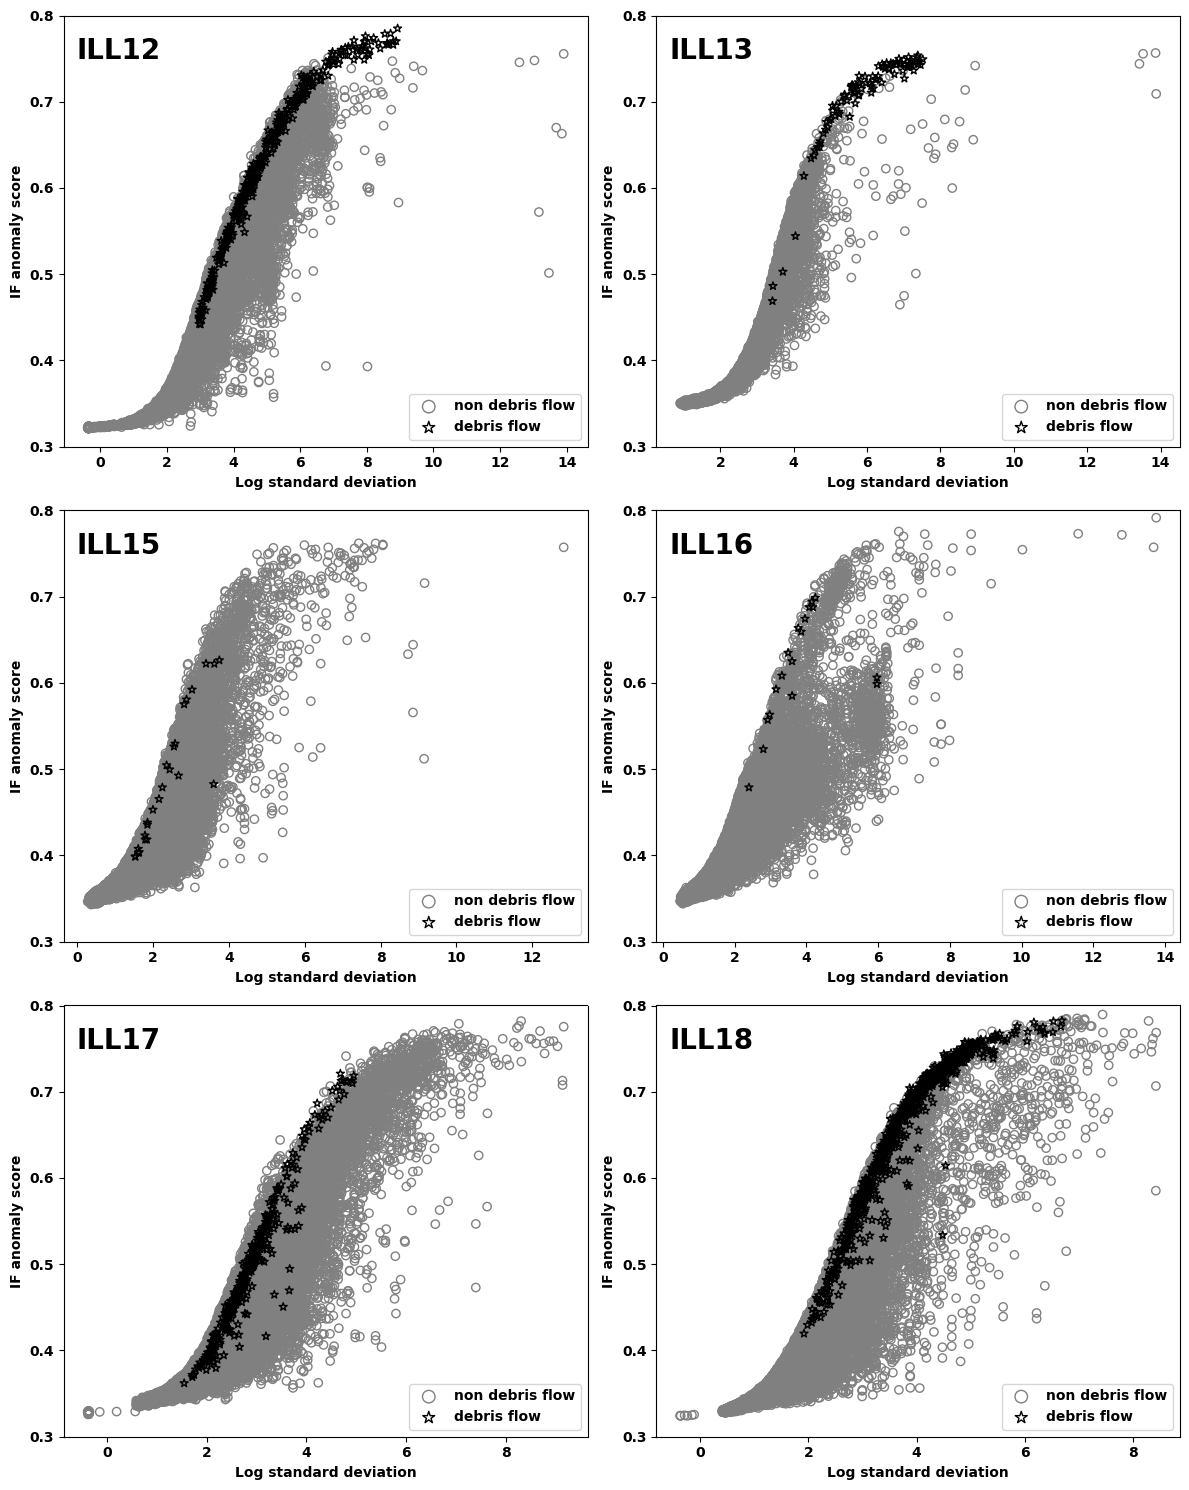

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
markers = ["o", "s", "d", "*"]
colors = ["gray", "k", "k", "k"]
label = ["non debris flow", "low confidence", "med confidence", "debris flow"]

rcount = 0
ccount = 0

for station in ["ILL12", "ILL13", "ILL15", "ILL16", "ILL17", "ILL18"]:
    scores = scores_dict[station]
    labs = scores["label"]

    for l in [0, 3]:
        axes[rcount][ccount].scatter(
            np.log(scores["std"][labs == l]),
            scores["anomaly_score"][labs == l],
            marker=markers[l],
            facecolors="none",
            edgecolors=colors[l],
            rasterized=True,
            label=label[l],
        )

    axes[rcount][ccount].set_xlabel("Log standard deviation", fontweight="bold")
    axes[rcount][ccount].set_ylabel("IF anomaly score", fontweight="bold")
    # .set_title(station, fontweight="bold")
    axes[rcount][ccount].text(
        0.025,
        0.90,
        station,
        transform=axes[rcount][ccount].transAxes,
        fontsize=20,
        fontweight="bold",
    )
    axes[rcount][ccount].legend(
        loc="lower right", prop={"weight": "bold"}, markerscale=1.5
    )
    axes[rcount][ccount].set_ylim(0.3, 0.8)

    if ccount == 1:
        ccount = 0
        rcount += 1
    else:
        ccount = 1

for ax in axes.flat:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("../plots/ILL_rest.pdf", dpi=300)
plt.show()

In [13]:
del scores_dict

###  Dynamic Time Warping

In [14]:
paths = find_paths("XP", "ILL18", "EHZ.D", start=2018, stop=2022)

In [15]:
station = "ILL18"
network = "XP"
dtw_path = f"../output/{network}/dtw/reference_segments"
model_path = f"../output/{network}/if/models/"

In [16]:
if_mod = load(f"{model_path}/{station}.joblib")

with open(f"{dtw_path}/{station}_pairwise", "rb") as f:
    indices, results = pickle.load(f)

ref_segments_df = pd.read_csv(f"{dtw_path}/{station}.csv")
ref_segments_df = preproc_flow_annotations(ref_segments_df)

In [17]:
ref = ref_segments_df.loc[14]
st = obspy.read(find_date_in_strings(paths, str(ref["start"])[:10])[0])
preproc_stream(st)
lag = timedelta(seconds=18 * 50)
st.trim(ref["start"] + lag, ref["start"] + lag + 99.99)
window1 = st[0].copy()


ref = ref_segments_df.loc[0]
st = obspy.read(find_date_in_strings(paths, str(ref["start"])[:10])[0])
preproc_stream(st)
lag = timedelta(seconds=4 * 50)
st.trim(ref["start"] + lag, ref["start"] + lag + 99.99)
window2 = st[0].copy()

In [18]:
x = window1.data
y = window2.data
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

distance, path = fastdtw(x, y, radius=10)

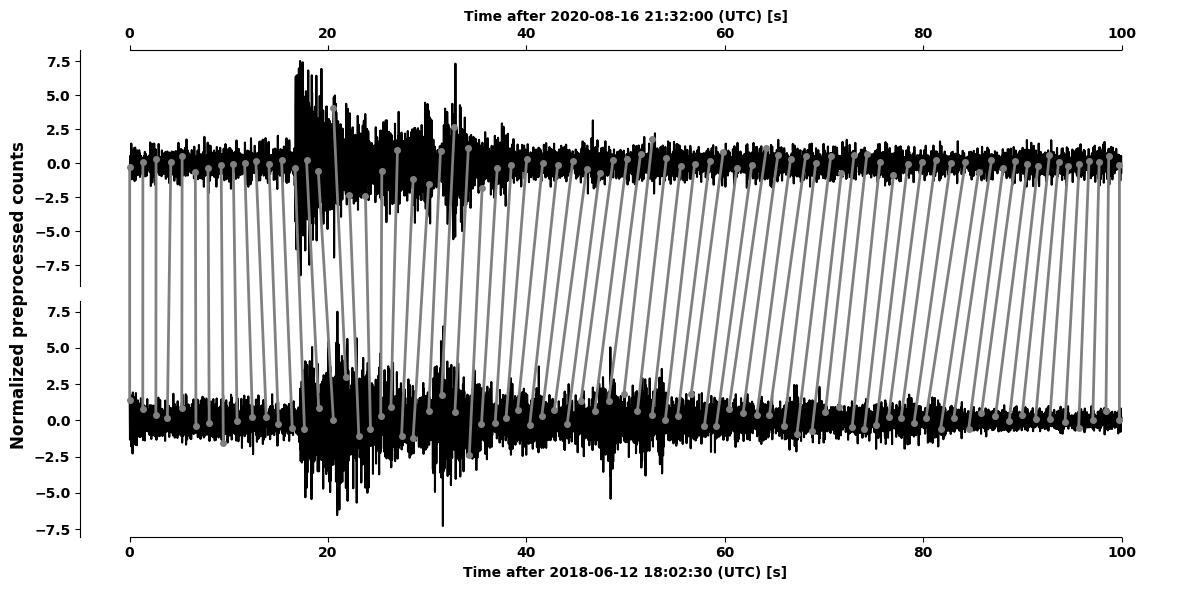

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

sec = (np.arange(len(x))) * 0.01

ax1.plot(sec, x, color="k")
ax2.plot(sec, y, color="k")

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(False)

ax1.spines["top"].set_bounds(sec.min(), sec.max())
ax2.spines["bottom"].set_bounds(sec.min(), sec.max())

ax1.spines["top"].set_visible(True)
ax2.spines["bottom"].set_visible(True)

ax1.spines["left"].set_visible(True)
ax2.spines["left"].set_visible(True)

ax1.xaxis.tick_top()
ax2.xaxis.tick_bottom()
ax1.yaxis.tick_left()
ax2.yaxis.tick_left()

subsample = max(1, len(path) // 75)
for i, j in path[::subsample]:
    ax1.plot(sec[i], x[i], "o", color="gray", markersize=4, zorder=2)
    ax2.plot(sec[j], y[j], "o", color="gray", markersize=4, zorder=2)
    con = ConnectionPatch(
        xyA=(sec[i], x[i]),
        coordsA=ax1.transData,
        xyB=(sec[j], y[j]),
        coordsB=ax2.transData,
        color="gray",
        alpha=1,
        linewidth=2.0,
    )
    con.set_in_layout(False)
    fig.add_artist(con)

time1 = (
    "Time after " + str(window1.stats.starttime)[:19].replace("T", " ") + " (UTC) [s]"
)
time2 = (
    "Time after " + str(window2.stats.starttime)[:19].replace("T", " ") + " (UTC) [s]"
)

ax1.set_xlabel(time1, fontweight="bold")
ax1.xaxis.set_label_position("top")

ax2.set_xlabel(time2, fontweight="bold")

fig.supylabel("Normalized preprocessed counts", fontweight="bold")


for ax in (ax1, ax2):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("../plots/time_window_dtw.pdf", dpi=300)
plt.show()

In [20]:
t0 = ref_segments_df.loc[1, "start"]
t1 = ref_segments_df.loc[1, "stop"]

seg1 = limit_segment_length(t0, t1, paths, if_mod)
t0 = seg1[2]
t1 = seg1[3] - timedelta(seconds=0.01)

flow1_st = obspy.read(find_date_in_strings(paths, str(t0)[:10])[0])
preproc_stream(flow1_st)
flow1_st.trim(t0, t1)

t0 = ref_segments_df.loc[2, "start"]
t1 = ref_segments_df.loc[2, "stop"]

seg2 = limit_segment_length(t0, t1, paths, if_mod)
t0 = seg2[2]
t1 = seg2[3] - timedelta(seconds=0.01)

flow2_st = obspy.read(find_date_in_strings(paths, str(t0)[:10])[0])
preproc_stream(flow2_st)
flow2_st.trim(t0, t1)

flow1 = flow1_st[0].data
flow1_scores = seg1[1]
flow2 = flow2_st[0].data
flow2_scores = seg2[1]

dtw_res = segment_dtw(seg1, seg2)
A = dtw_res[1]

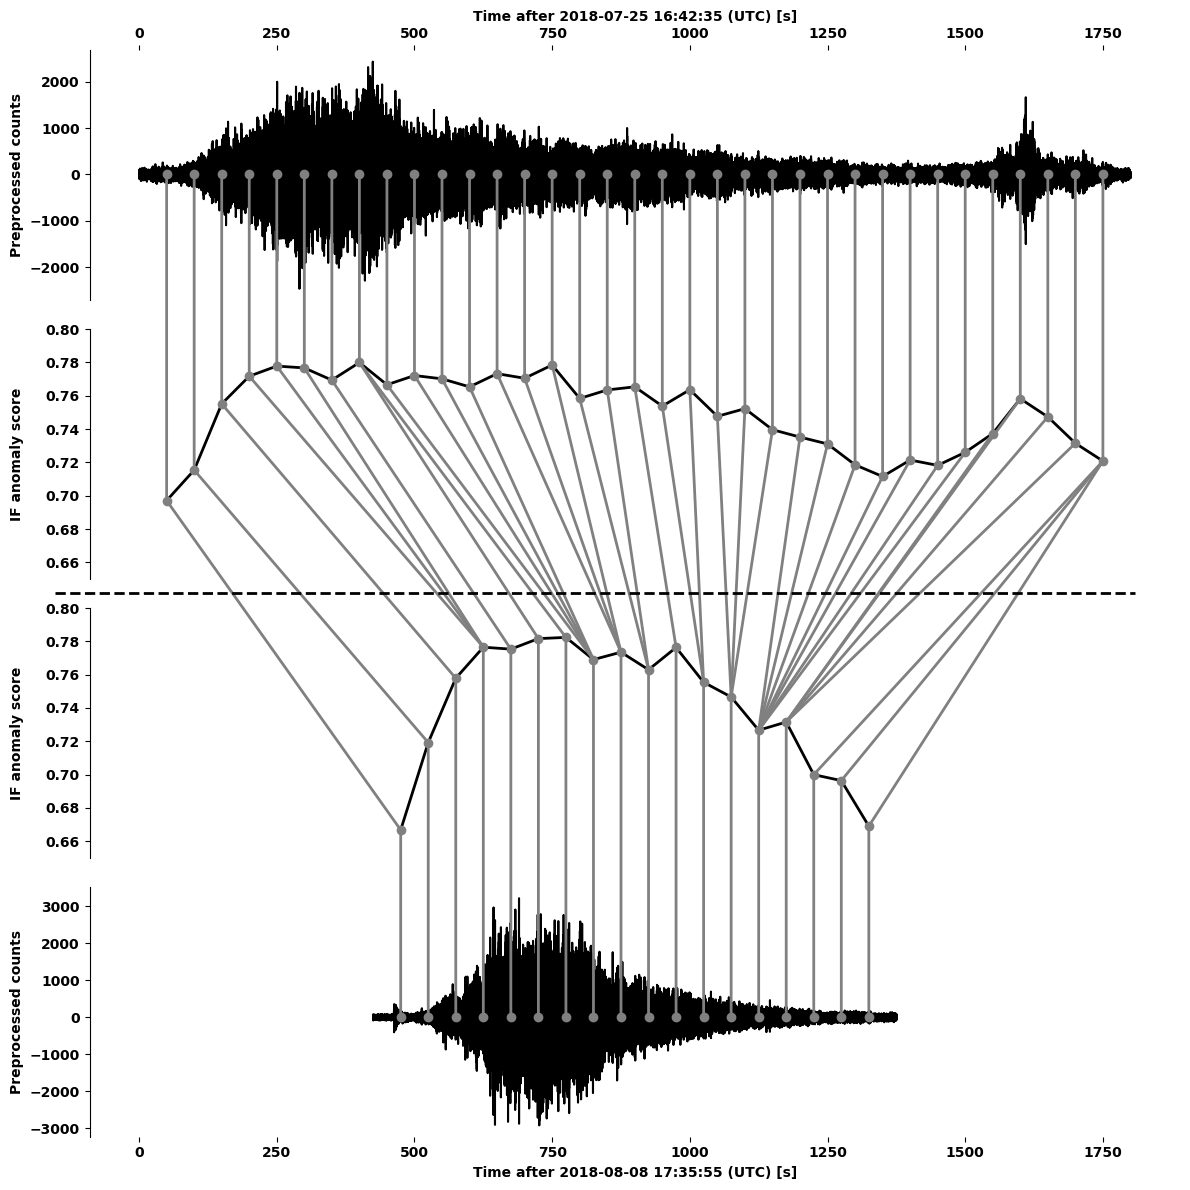

In [21]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

times1 = np.arange(len(flow1)) * 0.01
ax1.plot(times1, flow1, color="k")

ax2.plot(times1[5000::5000], flow1_scores, color="k", linewidth=2)
ax2.set_ylim(0.65, 0.8)

times2 = 425 + np.arange(len(flow2)) * 0.01
ax4.plot(times2, flow2, color="k")

ax3.plot(times2[5000::5000], flow2_scores, color="k", linewidth=2)
ax3.set_ylim(0.65, 0.8)

for ax in (ax1, ax2, ax3, ax4):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

ax2.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax3.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

ax1.tick_params(
    axis="x", which="both", top=True, labeltop=True, bottom=False, labelbottom=False
)

ax1.xaxis.set_ticks_position("top")
ax1.xaxis.set_label_position("top")

x_scores = times1[5000::5000]

for x, y2 in zip(x_scores, flow1_scores):
    idx = int(x / 0.01)
    y1 = flow1[idx]

    ax1.plot(x, 0, "o", color="gray", markersize=6, zorder=3)
    ax2.plot(x, y2, "o", color="gray", markersize=6, zorder=3)

    con = ConnectionPatch(
        xyA=(x, 0),
        coordsA=ax1.transData,
        xyB=(x, y2),
        coordsB=ax2.transData,
        color="gray",
        linewidth=2.0,
        alpha=1.0,
    )
    fig.add_artist(con)

indices2 = np.arange(len(flow2))[5000::5000]

for i, y3 in zip(indices2, flow2_scores):
    x = times2[i]
    y4 = flow2[i]

    ax4.plot(x, 0, "o", color="gray", markersize=6, zorder=3)
    ax3.plot(x, y3, "o", color="gray", markersize=6, zorder=3)

    con = ConnectionPatch(
        xyA=(x, 0),
        coordsA=ax4.transData,  # raw signal
        xyB=(x, y3),
        coordsB=ax3.transData,  # score point
        color="gray",
        linewidth=2.0,
        alpha=1.0,
    )
    fig.add_artist(con)

x_scores1 = times1[5000::5000]
x_scores2 = times2[5000::5000]

for i, j in A:
    # get coordinates in ax2
    x2 = x_scores1[i]
    y2 = flow1_scores[i]

    # get coordinates in ax3
    x3 = x_scores2[j]
    y3 = flow2_scores[j]

    con = ConnectionPatch(
        xyA=(x2, y2),
        coordsA=ax2.transData,
        xyB=(x3, y3),
        coordsB=ax3.transData,
        color="gray",
        linewidth=2.0,
        alpha=1.0,
    )
    fig.add_artist(con)

ax1.set_ylabel("Preprocessed counts", fontweight="bold")
ax2.set_ylabel("IF anomaly score", fontweight="bold")
ax3.set_ylabel("IF anomaly score", fontweight="bold")
ax4.set_ylabel("Preprocessed counts", fontweight="bold")

t = str(flow1_st[0].stats.starttime - timedelta(seconds=425)).replace("T", " ")[:19]
ax1.set_xlabel(f"Time after {t} (UTC) [s]", fontweight="bold")
t = str(flow2_st[0].stats.starttime - timedelta(seconds=425)).replace("T", " ")[:19]
ax4.set_xlabel(f"Time after {t} (UTC) [s]", fontweight="bold")

for ax in (ax1, ax2, ax3, ax4):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()

pos2 = ax2.get_position()
pos3 = ax3.get_position()

y_sep = (pos2.y0 + pos3.y1) / 2  # midpoint between them

line = plt.Line2D(
    [0.05, 0.95],  # left to right (slight margin)
    [y_sep, y_sep],
    transform=fig.transFigure,
    color="k",
    linestyle="--",
    linewidth=2.0,
    alpha=1,
)

fig.add_artist(line)
fig.align_ylabels()

plt.savefig("../plots/segment_dtw.pdf", dpi=300)

plt.show()

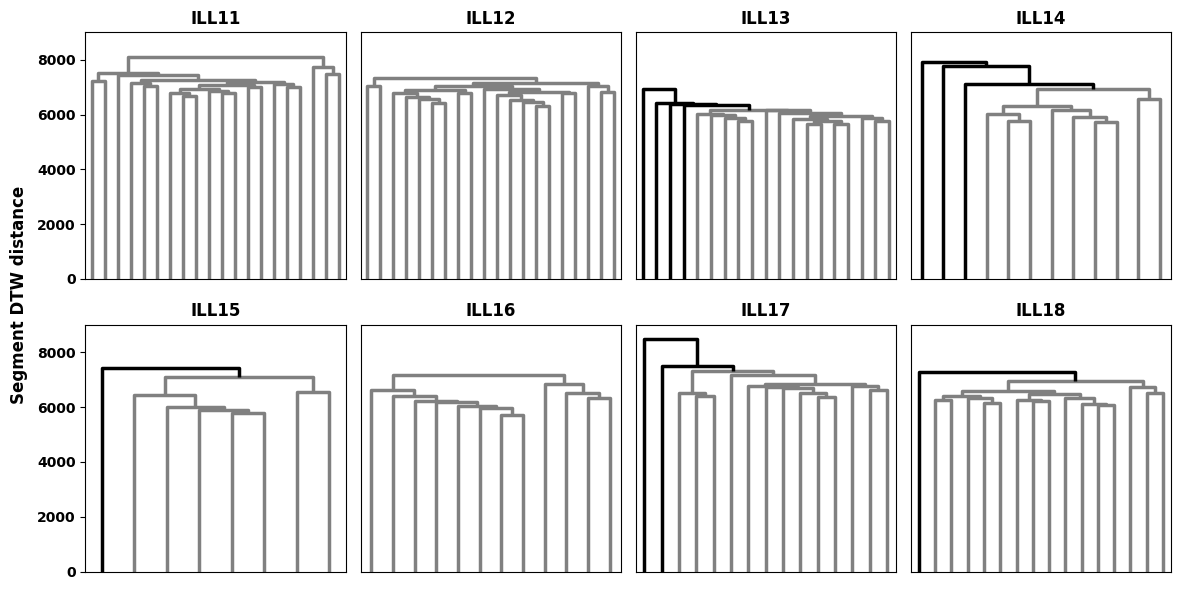

In [141]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
network = "XP"

higlights_dict = {
    "ILL11": {},
    "ILL12": {},
    "ILL13": {0, 1, 3, 4},
    "ILL14": {2, 5, 10},
    "ILL15": {6},
    "ILL16": {},
    "ILL17": {0, 1},
    "ILL18": {0},
}

row = 0
col = 0

for station in ill_stations:
    dtw_path = f"../output/{network}/dtw/reference_segments/{station}_pairwise"

    with open(dtw_path, "rb") as f:
        indices, results = pickle.load(f)

    nseg = max(indices)[1] + 1
    D = np.zeros([nseg, nseg])

    for k in range(len(indices)):
        i, j = indices[k]
        D[i, j] = np.median(results[k][0])
        D[j, i] = D[i, j]

    Dsqf = squareform(D)
    Z = linkage(Dsqf, method="complete")

    highlight = higlights_dict[station]

    if len(highlight) == 0:

        def link_color_func(k):
            return "gray"

    else:
        clusters = {i: {i} for i in range(nseg)}
        for i, (c1, c2, _, _) in enumerate(Z):
            c1, c2 = int(c1), int(c2)
            clusters[nseg + i] = clusters[c1] | clusters[c2]

        def link_color_func(k):
            return "black" if clusters[k] & highlight else "gray"

    dendrogram(
        Z,
        link_color_func=link_color_func,
        ax=axes[row, col],
        labels=np.repeat("", nseg),
    )
    axes[row, col].set_ylim(0, 9000)
    axes[row, col].set_title(station, fontweight="bold")

    if col != 0:
        axes[row, col].yaxis.set_visible(False)

    if col == 0:
        for label in (
            axes[row, col].get_xticklabels() + axes[row, col].get_yticklabels()
        ):
            label.set_fontweight("bold")

    col += 1
    if col == 4:
        col = 0
        row += 1

for ax in axes.flatten():
    for coll in ax.collections:
        coll.set_linewidth(2.5)

plt.tight_layout(rect=[0.03, 0, 1, 1])
fig.supylabel("Segment DTW distance", fontweight="bold")
plt.savefig("../plots/XP_dendros.pdf", dpi=300)
plt.show()

### XP summary stats

In [10]:
# Find starting- and ending date in XP miniseed recordings
network = "XP"
starttimes = []

for station in ill_stations:
    if station == "ILL11":
        channel = "HHZ.D"
    else:
        channel = "EHZ.D"

    paths = find_paths(network, station, channel, start=2018, stop=2018)
    starttimes.append(obspy.read(paths[0])[0].stats.starttime)

print("start:", min(starttimes))

endtimes = []

for station in ill_stations:
    if station == "ILL11":
        channel = "HHZ.D"
    else:
        channel = "EHZ.D"

    paths = find_paths(network, station, channel, start=2022, stop=2022)
    endtimes.append(obspy.read(paths[-1])[-1].stats.endtime)

print("end:", max(endtimes))

start: 2018-04-10T00:00:00.000000Z
end: 2022-08-28T21:24:02.970000Z


In [ ]:
summary_stats = {}

for station in ill_stations:
    if station == "ILL11":
        channel = "HHZ.D"
    else:
        channel = "EHZ.D"

    summary_stats[station] = {}

    for year in [2018, 2019, 2020, 2021, 2022]:
        paths = find_paths(network, station, channel, start=year, stop=year)
        summary_stats[station][year] = {"n_records": len(paths)}

        num_samples = 0
        for p in paths:
            for tr in obspy.read(p):
                num_samples += tr.stats.npts

        summary_stats[station][year]["n_samples"] = num_samples

df = pd.DataFrame.from_dict(summary_stats, orient="index")
df.to_csv("../plots/XP_summary_stats.csv")

In [24]:
df = pd.read_csv("../plots/XP_summary_stats.csv", index_col=0)


def parse_cell(cell):
    try:
        if pd.isna(cell):
            return ""

        d = ast.literal_eval(cell)

        n_records = d["n_records"]
        n_samples = f"{d['n_samples']:,}"

        return f"\\makecell{{{n_records} \\\\ {n_samples}}}"

    except Exception:
        return ""


df_clean = df.map(parse_cell)

latex_table = df_clean.to_latex(escape=False)

print(latex_table)

\begin{tabular}{llllll}
\toprule
 & 2018 & 2019 & 2020 & 2021 & 2022 \\
\midrule
ILL11 & \makecell{130 \\ 1,114,064,574} & \makecell{155 \\ 1,330,498,078} & \makecell{140 \\ 1,202,056,672} & \makecell{148 \\ 1,267,142,728} & \makecell{95 \\ 771,963,166} \\
ILL12 & \makecell{123 \\ 1,050,286,704} & \makecell{172 \\ 1,466,552,357} & \makecell{144 \\ 1,221,974,157} & \makecell{72 \\ 598,765,256} & \makecell{111 \\ 953,626,064} \\
ILL13 & \makecell{122 \\ 1,045,012,833} & \makecell{163 \\ 1,382,823,864} & \makecell{160 \\ 2,399,407,988} & \makecell{149 \\ 1,270,807,077} & \makecell{111 \\ 952,407,056} \\
ILL14 & \makecell{124 \\ 1,047,005,509} & \makecell{163 \\ 1,480,274,085} & \makecell{143 \\ 1,269,611,815} & \makecell{173 \\ 1,478,024,717} & \makecell{112 \\ 946,655,226} \\
ILL15 & \makecell{86 \\ 733,166,663} & \makecell{106 \\ 887,423,288} & \makecell{161 \\ 2,462,657,197} & \makecell{108 \\ 982,738,337} & \makecell{75 \\ 631,977,746} \\
ILL16 & \makecell{86 \\ 733,993,359} & \makece

In [28]:
# WSL summaries
wsl_catalog = pd.read_csv("../catalogs/XP/initial_catalog.csv")
wsl_catalog = wsl_catalog[wsl_catalog["confidence"] != "earthquake"].reset_index(
    drop=True
)
wsl_catalog = wsl_catalog[wsl_catalog["confidence"] != "quarrywork"].reset_index(
    drop=True
)
wsl_catalog = wsl_catalog[wsl_catalog["confidence"] != "rockfall"].reset_index(
    drop=True
)
flow_catalog = pd.read_csv("../catalogs/XP/flow_catalog.csv")
catalog_dict = {}

catalog_dict = {}
for station in ill_stations:
    catalog_dict[station] = {}

    for year in [2018, 2019, 2020, 2021, 2022]:
        initial_catalog = (
            wsl_catalog[np.array([str(year) in i for i in wsl_catalog["start"]])]
            .copy()
            .reset_index(drop=True)
        )
        initial_catalog = initial_catalog[
            initial_catalog["station"] == station
        ].reset_index(drop=True)
        final_catalog = (
            flow_catalog[np.array([str(year) in i for i in flow_catalog["start"]])]
            .copy()
            .reset_index(drop=True)
        )
        final_catalog = final_catalog[final_catalog["station"] == station].reset_index(
            drop=True
        )

        before = (
            np.sum(initial_catalog["confidence"] == "low"),
            np.sum(initial_catalog["confidence"] == "med"),
            np.sum(initial_catalog["confidence"] == "high"),
        )
        after = (
            np.sum(final_catalog["confidence"] == "low"),
            np.sum(final_catalog["confidence"] == "med"),
            np.sum(final_catalog["confidence"] == "high"),
        )
        catalog_dict[station][year] = np.vstack([before, after])

df = pd.DataFrame.from_dict(catalog_dict, orient="index")

In [40]:
print(wsl_catalog["confidence"].value_counts())
print(flow_catalog["confidence"].value_counts())

confidence
high    240
med      24
low      15
Name: count, dtype: int64
confidence
high    257
low     197
med      44
Name: count, dtype: int64


In [34]:
def parse_cell(cell):
    top = cell[0]
    bottom = cell[1]

    top_str = " / ".join(map(str, top))
    bottom_str = " / ".join(map(str, bottom))

    return f"\\makecell{{{top_str} \\\\ {bottom_str}}}"


df_clean = df.map(parse_cell)
latex_table = df_clean.to_latex(escape=False)

print(latex_table)

\begin{tabular}{llllll}
\toprule
 & 2018 & 2019 & 2020 & 2021 & 2022 \\
\midrule
ILL11 & \makecell{0 / 0 / 4 \\ 1 / 1 / 3} & \makecell{0 / 0 / 9 \\ 6 / 1 / 11} & \makecell{0 / 0 / 7 \\ 2 / 0 / 9} & \makecell{1 / 2 / 11 \\ 2 / 2 / 14} & \makecell{0 / 0 / 2 \\ 2 / 0 / 2} \\
ILL12 & \makecell{0 / 0 / 4 \\ 0 / 0 / 5} & \makecell{0 / 0 / 9 \\ 1 / 2 / 12} & \makecell{0 / 0 / 7 \\ 2 / 1 / 10} & \makecell{0 / 1 / 6 \\ 1 / 1 / 10} & \makecell{0 / 0 / 4 \\ 2 / 1 / 4} \\
ILL13 & \makecell{0 / 0 / 3 \\ 1 / 1 / 2} & \makecell{0 / 0 / 9 \\ 1 / 1 / 12} & \makecell{0 / 0 / 7 \\ 0 / 0 / 10} & \makecell{1 / 2 / 11 \\ 1 / 2 / 14} & \makecell{0 / 0 / 4 \\ 0 / 0 / 4} \\
ILL14 & \makecell{0 / 1 / 1 \\ 0 / 1 / 1} & \makecell{1 / 2 / 6 \\ 1 / 3 / 7} & \makecell{2 / 0 / 5 \\ 5 / 1 / 4} & \makecell{0 / 0 / 7 \\ 36 / 0 / 8} & \makecell{0 / 0 / 4 \\ 29 / 0 / 4} \\
ILL15 & \makecell{0 / 1 / 1 \\ 0 / 1 / 1} & \makecell{0 / 2 / 2 \\ 1 / 2 / 2} & \makecell{2 / 0 / 5 \\ 3 / 0 / 4} & \makecell{0 / 0 / 4 \\ 6 / 0 / 6} &

### DK Summary stats

In [71]:
network = "DK"
channel = "HHZ.D"

In [ ]:
summary_stats = {}

for station in ["NUUG", "NUUG_CONT", "KARAT", "KARAT_CONT"]:
    if "NUUG" in station:
        years = [2017]
    else:
        years = [2022, 2023]

    summary_stats[station] = {}

    paths = find_paths(
        network, station, channel, start=np.min(years), stop=np.max(years)
    )

    summary_stats[station] = {"n_records": len(paths)}

    num_samples = 0
    for p in paths:
        for tr in obspy.read(p):
            num_samples += tr.stats.npts

    summary_stats[station]["n_samples"] = num_samples

df = pd.DataFrame.from_dict(summary_stats, orient="index")
df.to_csv("../plots/DK_summary_stats.csv")

### Flow Time Series Plot

In [51]:
paths = {}
if_mods = {}

for station in ill_stations:
    if station == "ILL11":
        channel = "HHZ.D"
    else:
        channel = "EHZ.D"

    paths[station] = find_paths("XP", station, channel, start=2018, stop=2022)
    if_mods[station] = load(f"../output/XP/if/models/{station}.joblib")

In [52]:
start = obspy.UTCDateTime("2021-07-06T18:30:00.000000Z")
end = obspy.UTCDateTime("2021-07-06T20:00:00.000000Z")

In [53]:
plotting_data = {}
for station in ill_stations:
    st_new = obspy.read(find_date_in_strings(paths[station], "2021-07-06")[0])
    preproc_stream(st_new)
    st_new.trim(start, end)

    X, T = sliding_windows_from_trace(st_new[0])
    if_scores = -if_mods[station].score_samples(X)

    wf = st_new[0].data
    a = np.min(wf)
    b = np.max(wf)
    wf = (wf - a) / (b - a)

    plotting_data[station] = {
        "waveform": wf,
        "if_scores": if_scores,
        "times": np.array([t[1] for t in T]),
    }

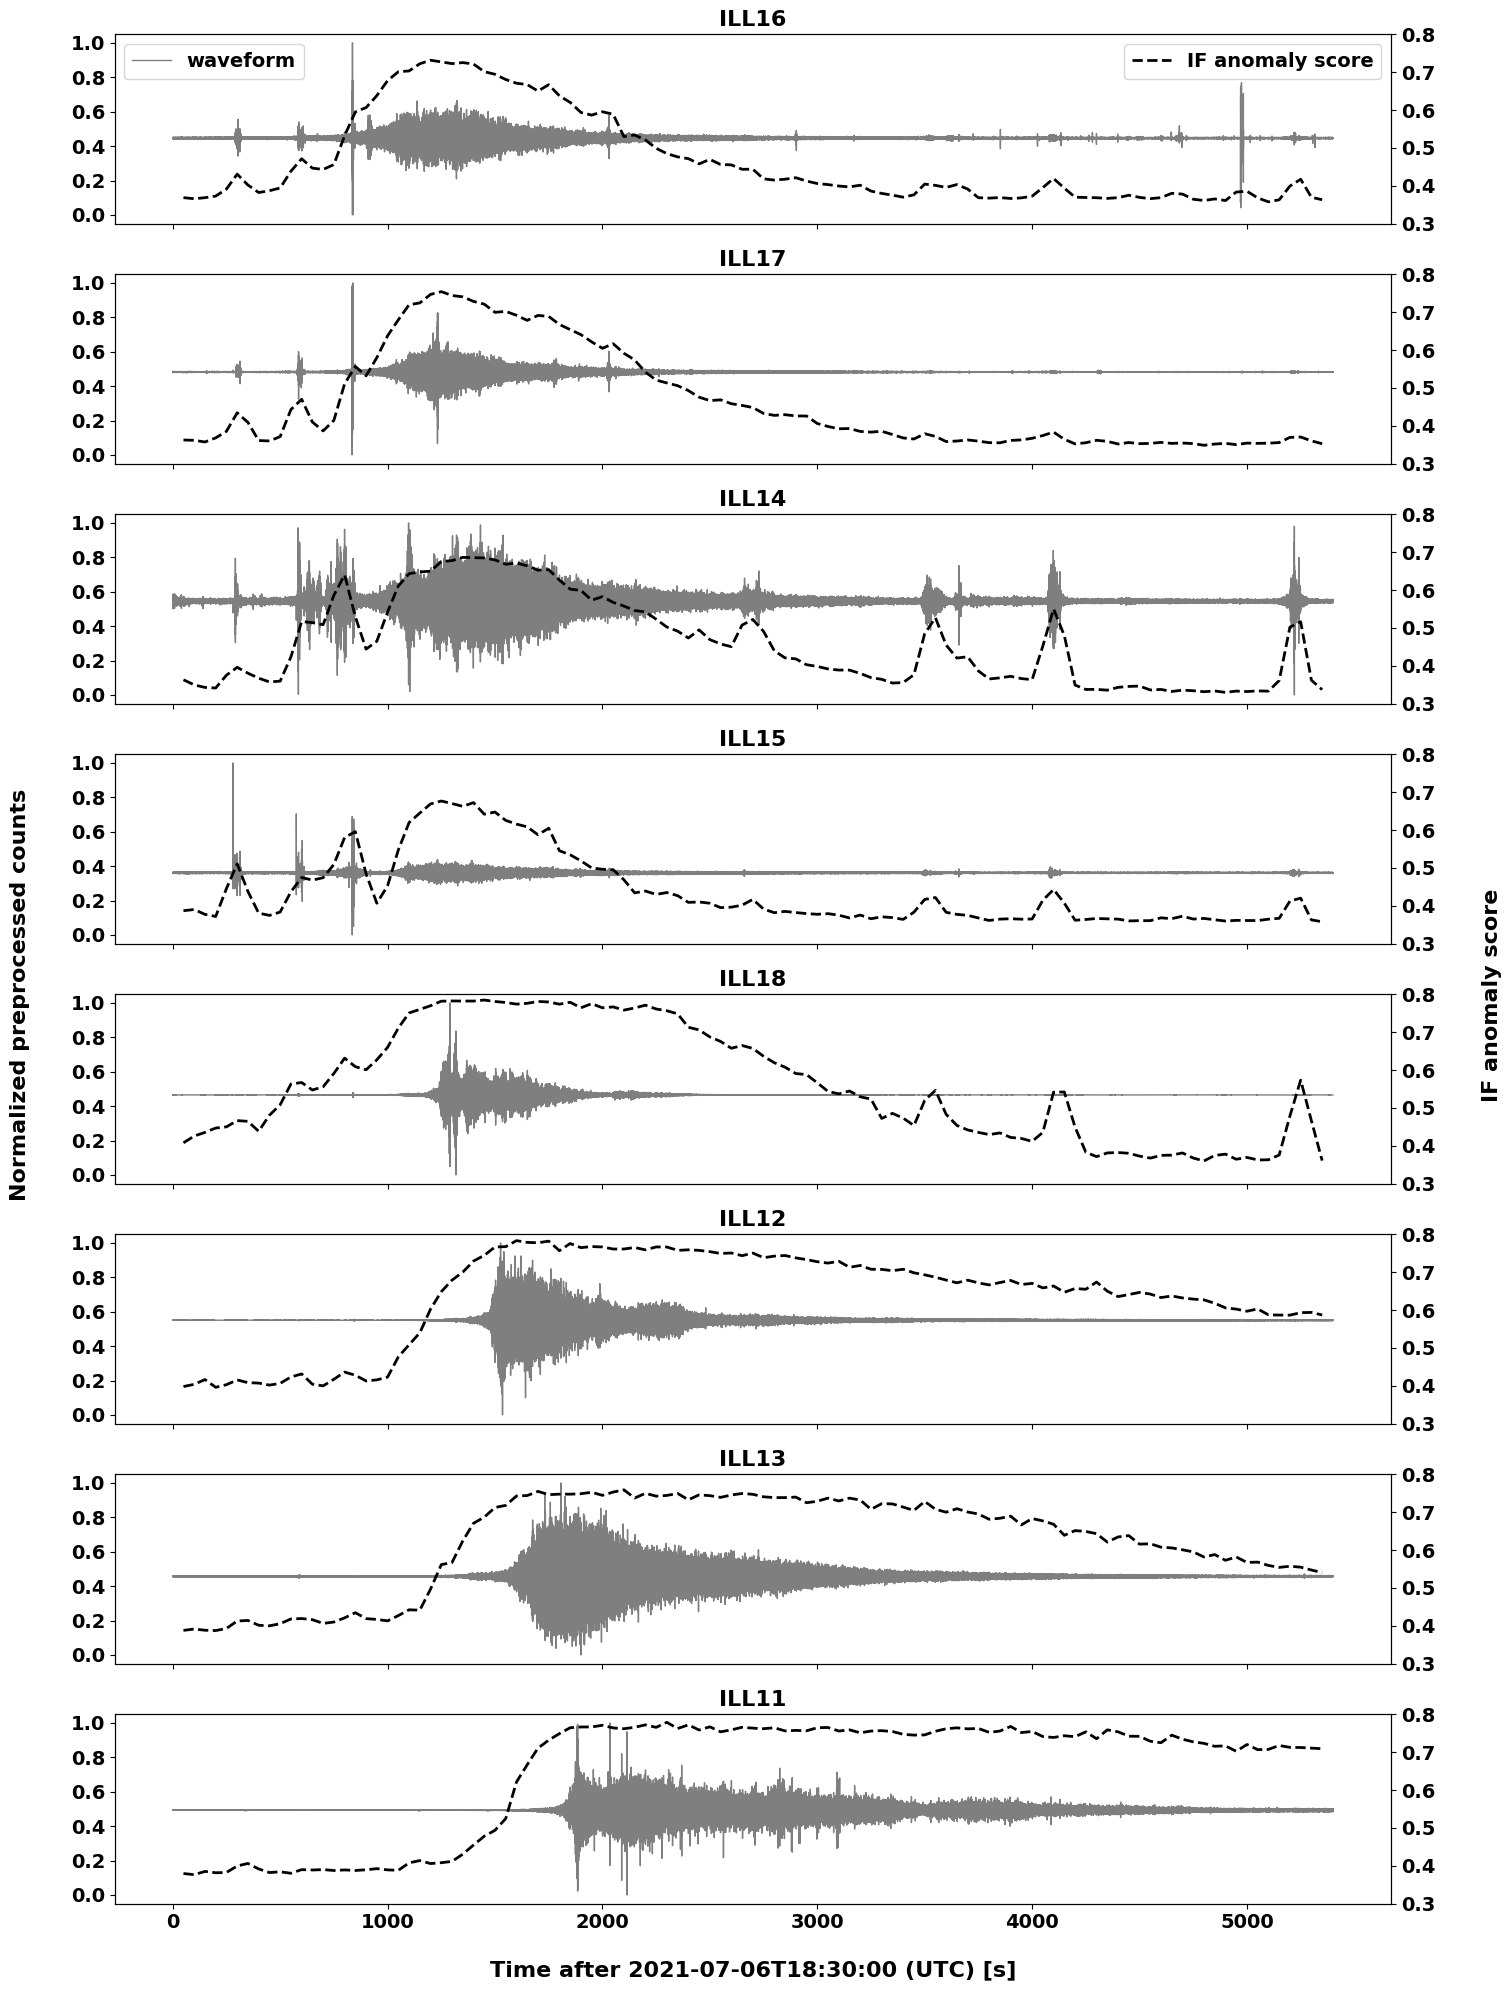

In [69]:
stations = ["ILL16", "ILL17", "ILL14", "ILL15", "ILL18", "ILL12", "ILL13", "ILL11"]

fig, axes = plt.subplots(8, 1, figsize=(16, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    wf = plotting_data[station]["waveform"]
    tt = np.arange(len(wf)) * 0.01
    ax.plot(tt, wf, linewidth=1, c="k", alpha=0.5, label="waveform")
    ax.set_title(station, fontweight="bold", fontsize=16)

    scores = plotting_data[station]["if_scores"]
    tt = (1 + np.arange(len(scores))) * 50
    ax2 = ax.twinx()
    ax2.plot(
        tt,
        scores,
        color="k",
        alpha=1.0,
        linestyle="dashed",
        linewidth=2,
        label="IF anomaly score",
    )
    ax2.set_ylim(0.3, 0.8)

    if station == "ILL16":
        ax.legend(loc="upper left", prop={"weight": "bold", "size": 14})
        ax2.legend(loc="upper right", prop={"weight": "bold", "size": 14})

    for label in ax2.get_xticklabels() + ax2.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(14)


t = "2021-07-06T18:30:00"
ax.set_xlabel(f"Time after {t} (UTC) [s]", fontweight="bold", fontsize=16, labelpad=20)

for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(14)

fig.text(
    0.04,
    0.5,
    "Normalized preprocessed counts",
    va="center",
    rotation="vertical",
    fontweight="bold",
    fontsize=16,
)

fig.text(
    0.96,
    0.5,
    "IF anomaly score",
    va="center",
    rotation="vertical",
    fontweight="bold",
    fontsize=16,
)

plt.tight_layout(rect=[0.06, 0, 0.94, 1])
plt.savefig("../plots/flow_ts_plot.pdf", dpi=300)
plt.show()

### Rock Avalanche

In [80]:
nuug_paths = find_paths("DK", "NUUG", "HHZ.D", start=2017, stop=2017)
ra_paths = [
    find_date_in_strings(nuug_paths, "2017-06-17")[0],
    find_date_in_strings(nuug_paths, "2017-06-18")[0],
]

scores_df = pd.read_csv(f"../output/DK/if/scores/NUUG.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

if_st = create_if_stream(scores_df, station="NUUG", sr=0.02, network="DK")


ra_tr = obspy.Trace()
st1 = obspy.read(ra_paths[0])
preproc_stream(st1)
st2 = obspy.read(ra_paths[1])
preproc_stream(st2)

st2.trim(
    starttime=st1[0].stats.endtime + timedelta(seconds=0.01),
    endtime=st2[0].stats.endtime,
)

ra_tr.data = np.concatenate((st1[0].data, st2[0].data))
ra_tr.stats.starttime = st1[0].stats.starttime
ra_tr.stats.sampling_rate = st1[0].stats.sampling_rate

t0 = obspy.UTCDateTime("2017-06-17T23:30:00.000000Z")
t1 = obspy.UTCDateTime("2017-06-18T00:30:00.000000Z")

ra_tr.trim(t0, t1)
if_tr = if_st.copy().trim(t0, t1)[0]

trigger_on = obspy.UTCDateTime("2017-06-17T23:39:11.680001Z") - t0
trigger_off = obspy.UTCDateTime("2017-06-18T00:17:31.680001Z") - t0

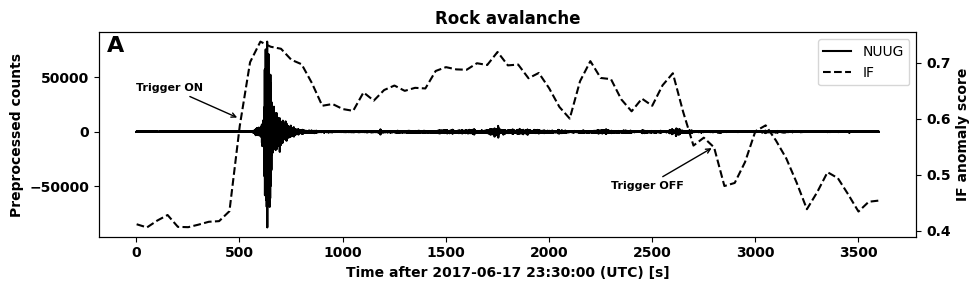

In [83]:
# waveform
npts1 = ra_tr.stats.npts
dt1 = 1 / ra_tr.stats.sampling_rate
start_offset = ra_tr.stats.starttime - t0
t1 = np.arange(0, npts1) * dt1 + +start_offset

npts2 = if_tr.stats.npts
dt2 = 1 / if_tr.stats.sampling_rate
start_offset = if_tr.stats.starttime - t0
t2 = np.arange(0, npts2) * dt2 + start_offset

fig, ax1 = plt.subplots(figsize=(10, 3))

ax1.plot(t1, ra_tr.data, color="black", label="NUUG")
ax1.set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)
ax1.set_ylabel("Preprocessed counts", color="black", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(t2, if_tr.data, color="black", label="IF", linestyle="--")
ax2.set_ylabel("IF anomaly score", color="black", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="black")

for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontweight("bold")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
ax1.text(
    0.01,
    0.98,
    "A",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)


plt.annotate(
    "Trigger ON",
    xy=(trigger_on - 50, 0.6),
    xytext=(0, 0.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.annotate(
    "Trigger OFF",
    xy=(trigger_off - 50, 0.55),
    xytext=(2300, 0.475),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.title("Rock avalanche", fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/rock_avalanche.pdf", dpi=300)
plt.show()

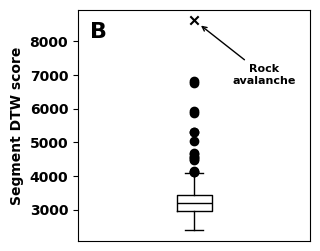

8618.74


In [103]:
with open(f"../output/DK/dtw/reference_segments/NUUG_pairwise", "rb") as f:
    indices, results = pickle.load(f)

n = max(indices)[1] + 1
d = np.array([np.median(i[0]) for i in results[1]])

D = np.zeros([n, n])
for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

condensed_D = squareform(D)
linkage_matrix = sch.linkage(condensed_D, method="complete")

hh = []

for i in range(linkage_matrix.shape[0]):
    if linkage_matrix[i, 0] < n or linkage_matrix[i, 1] < n:
        hh.append(linkage_matrix[i, 2])

hh = np.array(hh)

fig, ax = plt.subplots(figsize=(3, 3))
box = ax.boxplot(hh, patch_artist=False, flierprops=dict(marker=""))

IQR = np.quantile(hh, 0.75) - np.quantile(hh, 0.25)
up = np.quantile(hh, 0.75) + 1.5 * IQR

outliers = np.sort(hh[hh > up])

for i in range(outliers.shape[0] - 1):
    plt.scatter(1, outliers[i], c="k", marker="o")

plt.scatter(1, outliers[-1], c="k", marker="x")

ax.text(
    0.05,
    0.95,
    "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)

ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

for element in ["boxes", "whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

plt.ylabel("Segment DTW score", fontweight="bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.annotate(
    "Rock\navalanche",
    xy=(1.02, outliers[-1] - 100),
    xytext=(1.3, 7000),
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

# plt.tight_layout()
plt.savefig(
    "../plots/fig03.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
    pad_inches=0.1,
)
plt.show()

print(np.round(np.max(outliers), 2))

In [104]:
nuug_if_segments = pd.read_csv("../output/DK/if/segments/NUUG.csv")
print("Number of NUUG IF segments:", nuug_if_segments.shape[0])

Number of NUUG IF segments: 194


In [105]:
print(obspy.read(nuug_paths[0])[0].stats.starttime)
print(obspy.read(nuug_paths[-1])[0].stats.endtime)

2017-01-01T00:00:02.350001Z
2017-06-28T09:58:28.670000Z


In [106]:
nuug_cont_paths = find_paths("DK", "NUUG_CONT", "HHZ.D", start=2017, stop=2017)
print(obspy.read(nuug_cont_paths[0])[0].stats.starttime)
print(obspy.read(nuug_cont_paths[-1])[0].stats.endtime)

2017-01-01T00:00:00.678394Z
2018-01-01T00:00:04.598393Z


### KARAT Clustering

In [84]:
# load data and DTW distances
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)
control_paths = find_paths("DK", "KARAT_CONT", "HHZ.D", start=2022, stop=2023)

catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

if_mod = load(f"../output/{network}/if/models/{station}.joblib")

dtw_path = f"../output/{network}/dtw/distances/{station}.pkl"

with open(f"{dtw_path}", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [85]:
labs = np.array([""] * len(segments), dtype=object)
remark = np.array([""] * len(segments), dtype=object)

start_catalog = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs[i] = catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
            0
        ]
        start_catalog.append(catalog.iloc[np.where(np.append(I[0], np.diff(I)) > 0)[0]])
        remark[i] = catalog["remarks"][
            np.where(np.append(I[0], np.diff(I)) > 0)[0]
        ].values[0]
    except IndexError:
        labs[i] = None

In [86]:
# extract features and normalize
Xa = X.copy()
lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = lens.reshape(-1, 1)
Xa = np.hstack([Xa, lens])
Xa = np.hstack([Xa, segments[["scores", "control_scores"]].values])

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [87]:
# cluster segments based
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 20.76284980709905  ===>  99% of the (truncated) height range in dendro.
..done.


In [112]:
for cl in [2, 3, 5, 7, 10]:
    cluster = segments[segments["cluster"] == cl]
    months = cluster["start"].apply(lambda t: t.month)
    prop = ((months >= 9) | (months <= 1)).mean()
    print(f"Cluster {cl}: {prop}")

Cluster 2: 0.9701492537313433
Cluster 3: 0.8787878787878788
Cluster 5: 0.9655172413793104
Cluster 7: 0.9777777777777777
Cluster 10: 1.0


In [46]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy()
    info[cl] = cluster_info(cluster)

df = pd.DataFrame(info).T
df.index.name = "cluster"
df.fillna(0, inplace=True)
df = 100 * df
np.round(df, 2)

label,EQ,MM,N,None
cluster,,,,
1,0.00,0.00,0.00,100.00
2,0.00,0.00,0.00,100.00
3,1.52,0.00,1.52,96.97
4,0.00,0.00,1.61,98.39
5,0.00,0.00,0.00,100.00
6,86.54,5.77,7.69,0.00
7,0.00,0.00,0.00,100.00
8,0.00,86.36,13.64,0.00
9,0.00,100.00,0.00,0.00


In [47]:
print(
    "Mass movement segments:",
    np.sum(segments["label"] == "CAL") + np.sum(segments["label"] == "ID"),
)

Mass movement segments: 96


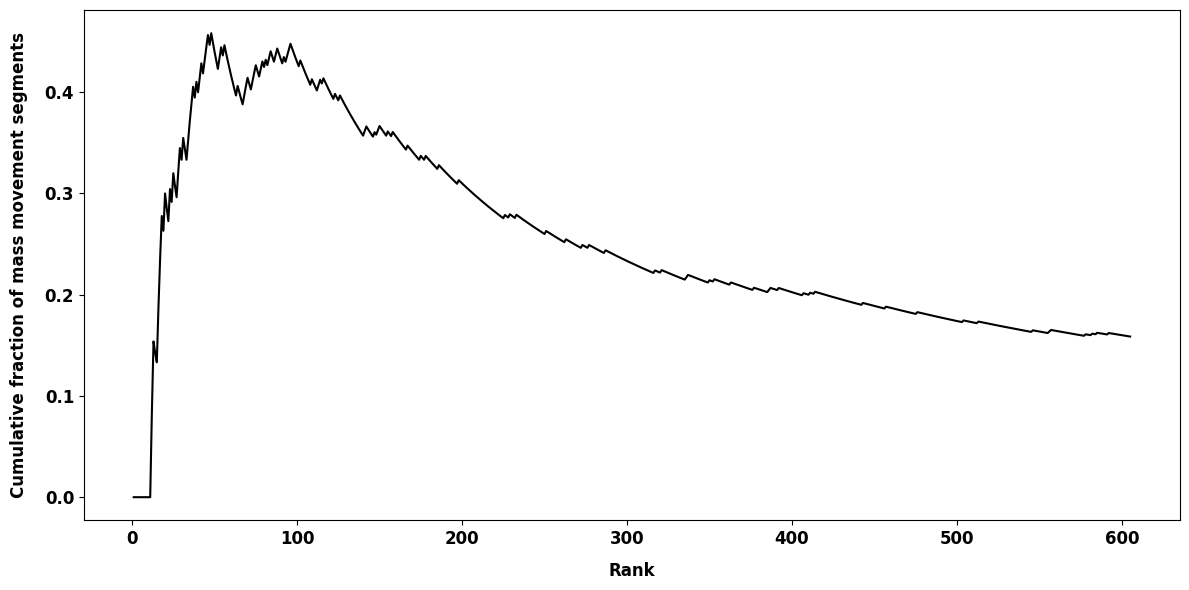

Maximizing k = 48, maximum prop = 45.83


In [48]:
mask = np.array(segments["label"] == "CAL") | np.array(segments["label"] == "ID")

x = np.arange(1, len(mask) + 1)
y = np.cumsum(mask) / np.arange(1, len(mask) + 1)


plt.figure(figsize=(12, 6))
plt.plot(x, y, c="k")
plt.xlabel("Rank", fontweight="bold", fontsize=12, labelpad=10)
plt.ylabel(
    "Cumulative fraction of mass movement segments",
    fontweight="bold",
    fontsize=12,
    labelpad=12,
)

ax = plt.gca()

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(12)

plt.tight_layout()
plt.savefig("../plots/cum_frac.pdf", dpi=300)
plt.show()

print(
    f"Maximizing k = {x[np.argmax(y)]}, maximum prop = {np.round(100 * np.max(y), 2)}"
)

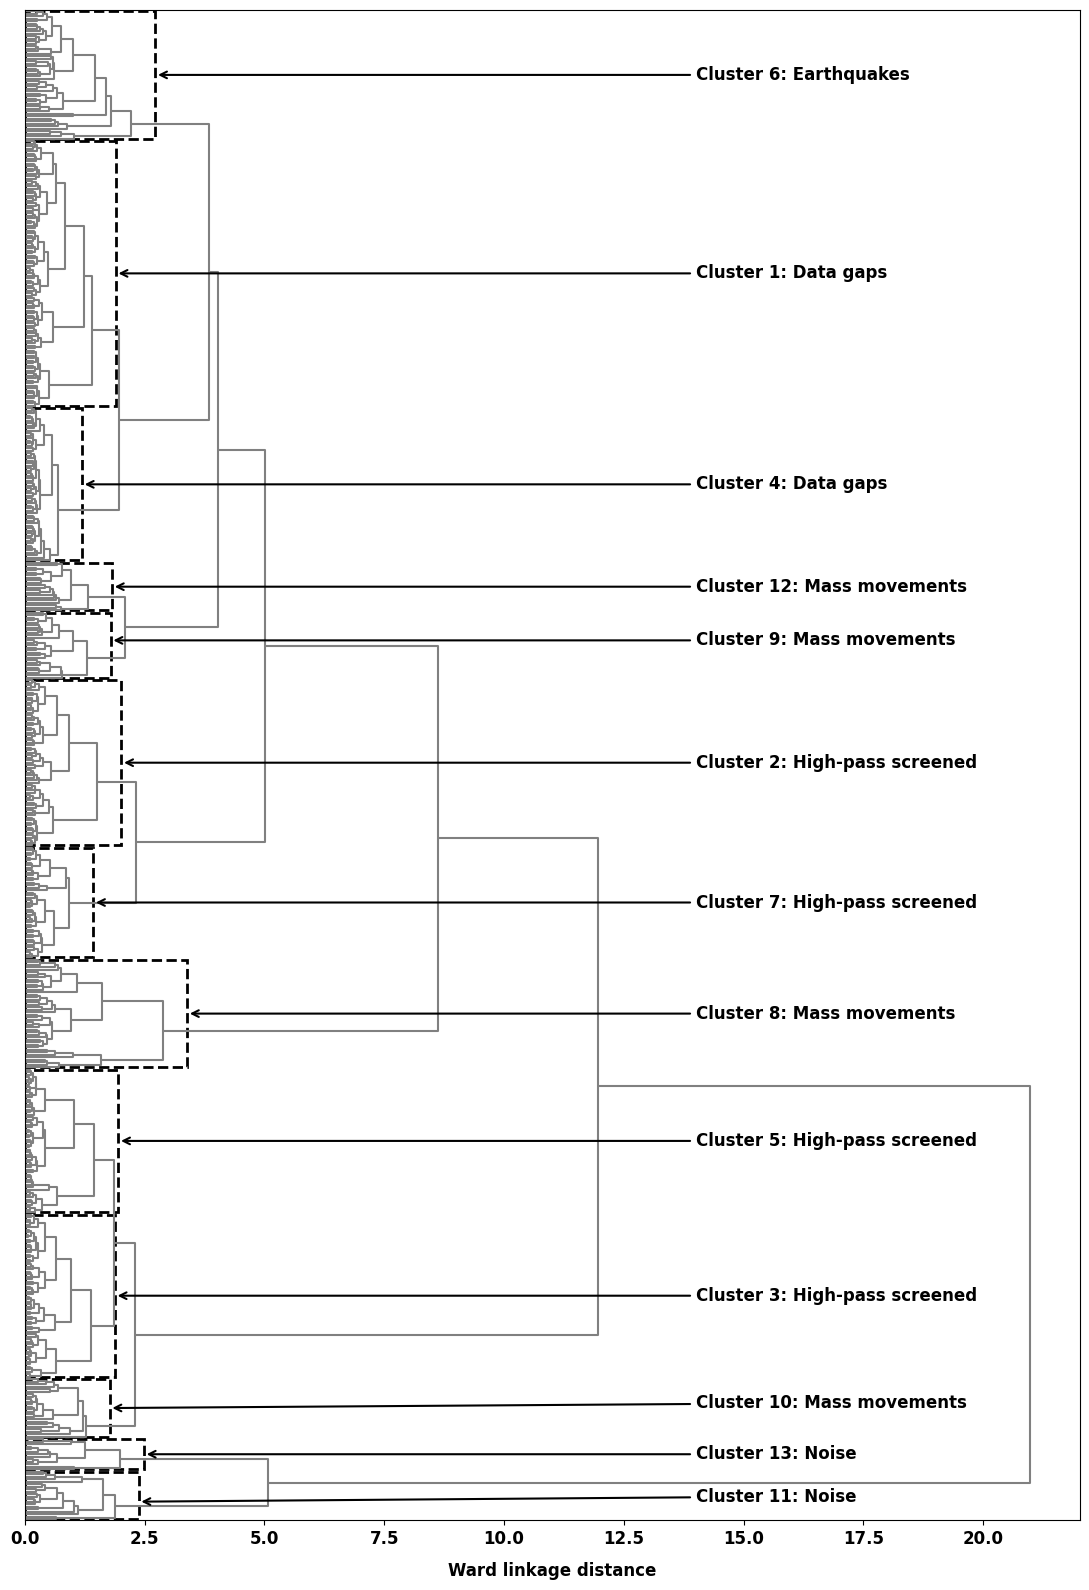

In [69]:
plt.figure(figsize=(11, 16))

ddata = dendrogram(
    Z, link_color_func=lambda k: "grey", orientation="right", no_labels=True
)

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()
x_positions = np.arange(len(leaf_order)) * 10 + 5

n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])


y_positions = np.arange(len(leaf_order)) * 10 + 5
gap = 5

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    y0 = y_positions[idx.min()] - 5 + gap
    y1 = y_positions[idx.max()] + 5 - gap
    width = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (0, y0),
        width,
        y1 - y0,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

    x_stop = 14.00

    if cid == 1:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 1: Data gaps",  # text
            xy=(x_start, y_center),  # arrow start (on box)
            xytext=(x_stop, y_center),  # text position (to the right)
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 2:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 2: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 3:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 3: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 4:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 4: Data gaps",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 5:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 5: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 6:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 6: Earthquakes",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 7:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 7: High-pass screened",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 8:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 8: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 9:
        y_center = (y0 + y1) / 2 + 20
        x_start = width

        ax.annotate(
            "Cluster 9: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 10:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 10: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 11:
        y_center = (y0 + y1) / 2 - 25
        x_start = width

        ax.annotate(
            "Cluster 11: Noise",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 12:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 12: Mass movements",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

    if cid == 13:
        y_center = (y0 + y1) / 2
        x_start = width

        ax.annotate(
            "Cluster 13: Noise",
            xy=(x_start, y_center),
            xytext=(x_stop, y_center),
            va="center",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
            ),
            fontweight="bold",
            fontsize=12,
        )

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(12)

plt.xlabel("Ward linkage distance", fontweight="bold", fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [ ]:
median_amplitudes = []
times = []

for p in karat_paths:
    st = obspy.read(p)
    preproc_stream(st)

    data = []

    for tr in st:
        data.append(tr.data)

    median_amplitudes.append(np.median(np.abs(np.concatenate(data))))

    year = st[0].stats.starttime.year
    month = st[0].stats.starttime.month
    day = st[0].stats.starttime.day
    times.append(pd.Timestamp(year=year, month=month, day=day))

    # print(times[-1],median_amplitudes[-1])

amplitide_df = pd.DataFrame({"times": times, "amplitudes": median_amplitudes})

scores_df = pd.read_csv(f"../output/DK/if/scores/KARAT.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]
karat_if_st = create_if_stream(scores_df, station="KARAT", sr=0.02, network="DK")

2022-05-30 00:00:00 5275.997364103325
2022-05-31 00:00:00 1236.8649226567522
2022-06-03 00:00:00 3212.6555434864367
2022-06-11 00:00:00 411.02760469623456
2022-06-12 00:00:00 441.155804765071
2022-06-13 00:00:00 557.8480793681078
2022-06-14 00:00:00 449.2162233737763
2022-06-15 00:00:00 210.03355607945434
2022-06-16 00:00:00 181.1800942181004
2022-08-15 00:00:00 38.24685352928278
2022-08-16 00:00:00 32.81647866020248
2022-08-17 00:00:00 18.957138305390274
2022-08-18 00:00:00 15.906187338625715
2022-08-19 00:00:00 17.577020277494547
2022-08-20 00:00:00 17.046915782281395
2022-08-21 00:00:00 16.645113469339172
2022-08-22 00:00:00 52.70025436747578
2022-08-23 00:00:00 49.1640193157034
2022-08-24 00:00:00 53.33496148668124
2022-08-25 00:00:00 30.150985138043353
2022-08-26 00:00:00 26.35720054369049
2022-08-27 00:00:00 19.235133804913048
2022-08-28 00:00:00 17.575907773720672
2022-08-29 00:00:00 30.72902531663746
2022-08-30 00:00:00 47.67454161785585
2022-08-31 00:00:00 32.87833727253094
20

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)


2022-09-17 00:00:00 31.462837239451908
2022-09-18 00:00:00 35.82678237101231
2022-09-19 00:00:00 27.03707236384334
2022-09-20 00:00:00 16.891480238404466
2022-09-21 00:00:00 19.256767630742935
2022-09-22 00:00:00 22.639288037046732
2022-09-23 00:00:00 26.64290516443097
2022-09-24 00:00:00 34.57162421034748
2022-09-25 00:00:00 66.79292290416453
2022-09-26 00:00:00 30.051380662725485
2022-09-27 00:00:00 19.288513510165004
2022-09-28 00:00:00 19.86105291073966
2022-09-29 00:00:00 31.015936284571755
2022-09-30 00:00:00 31.520900700130184
2022-10-01 00:00:00 40.67103837145769
2022-10-02 00:00:00 38.448353382951844
2022-10-03 00:00:00 29.543654241538007
2022-10-04 00:00:00 18.264370860660097
2022-10-05 00:00:00 27.018817441373955
2022-10-06 00:00:00 40.46010742732311
2022-10-07 00:00:00 37.57526580556781
2022-10-08 00:00:00 28.636470579973548
2022-10-09 00:00:00 31.315288765620352
2022-10-10 00:00:00 32.0597727296217
2022-10-11 00:00:00 28.256736224078413
2022-10-12 00:00:00 39.2931151340706

C:\Users\franc\AppData\Local\Temp\ipykernel_53756\2048165448.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


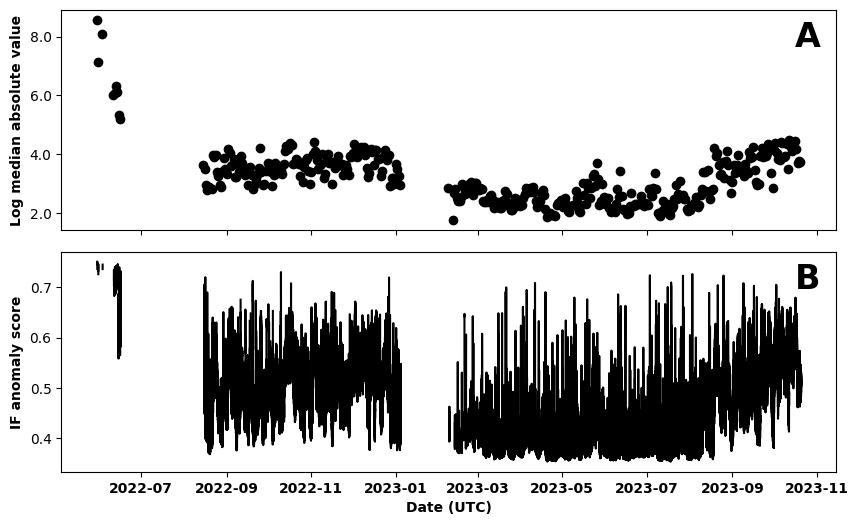

In [353]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6), gridspec_kw={"hspace": 0.1}
)

ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax1.scatter(amplitide_df["times"], np.log(amplitide_df["amplitudes"]), c="k")
ax1.set_ylabel("Log median absolute value", fontweight="bold")

ax1.text(
    0.98,
    0.95,
    "A",
    transform=ax1.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

for tr in karat_if_st:
    t = np.array(
        [tr.stats.starttime + i / tr.stats.sampling_rate for i in range(tr.stats.npts)]
    )
    t = np.array([ti.datetime for ti in t])
    ax2.plot(t, tr.data, color="black")

ax2.set_xlabel("Date (UTC)", fontweight="bold")
ax2.set_ylabel("IF anomaly score", fontweight="bold")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for label in ax2.get_xticklabels():
    label.set_fontweight("bold")

ax2.text(
    0.98,
    0.95,
    "B",
    transform=ax2.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

fig.tight_layout()
plt.savefig("../plots/fig05.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Appendix A

### Appendix D

In [ ]:
ill11_paths = find_paths("XP", "ILL11", "HHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill11_paths, "2018-06-12")[0]

st = obspy.read(example_path)
preproc_stream(st)
t0 = obspy.UTCDateTime("2018-06-12T03:00:00.000000Z")
t1 = obspy.UTCDateTime("2018-06-12T23:00:00.000000Z")

t0_gt = obspy.UTCDateTime("2018-06-12T19:05:00.000000Z")
t1_gt = obspy.UTCDateTime("2018-06-12T20:16:00.000000")

flow_start = t0_gt - t0
flow_stop = t1_gt - t0

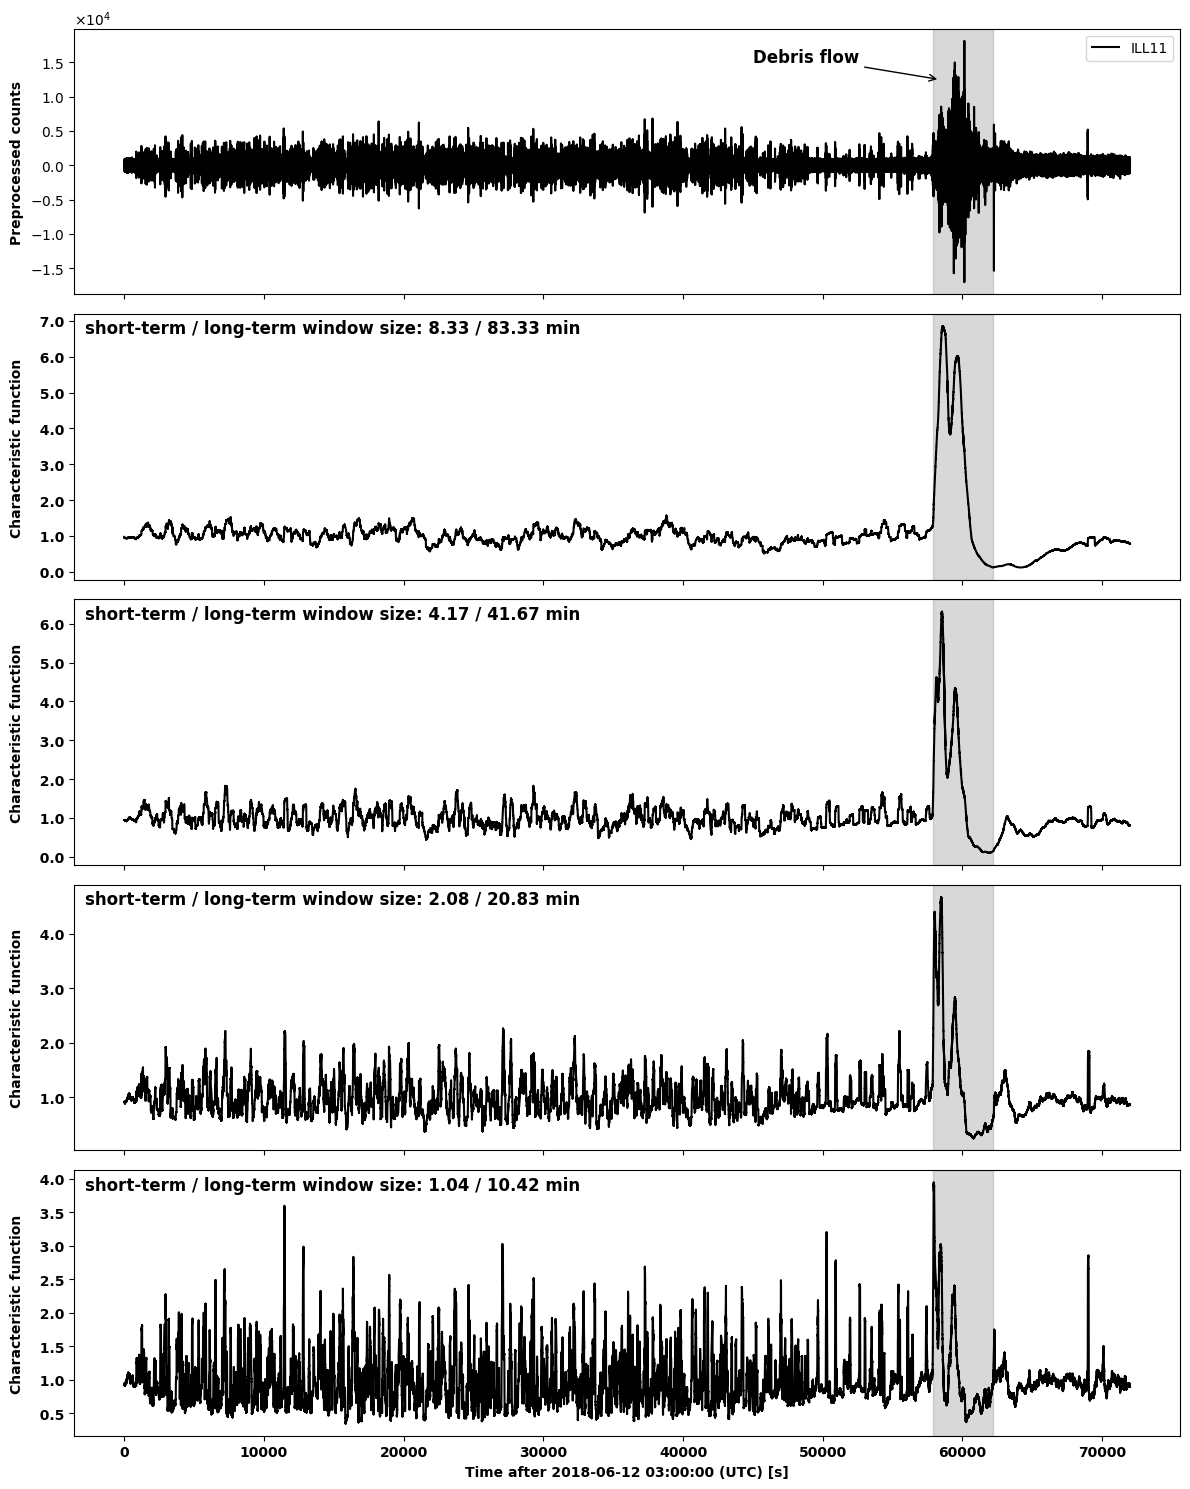

In [201]:
sw, lw = 50000, 500000
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
axs = axs.flatten()

for ax in axs:
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%5.1f"))

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL11")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start, flow_stop, color="gray", alpha=0.3)

axs[0].annotate(
    "Debris flow",
    xy=(flow_start + 500, 12500),
    xytext=(45000, 15000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

for h in range(1, 5):
    tr = st.copy()[0]
    tr = create_slta_trace(tr, sw, lw, station="ILL11")

    tr = tr.trim(t0, t1)
    npts = tr.stats.npts
    sampling_rate = tr.stats.sampling_rate
    dt = 1 / sampling_rate
    start_offset = tr.stats.starttime - t0
    t = np.arange(0, npts) * dt + start_offset
    axs[h].plot(t, tr.data, color="black")
    axs[h].set_ylabel("Characteristic function", fontweight="bold")

    if h < len(axs) - 1:
        axs[h].tick_params(labelbottom=False)

    axs[h].text(
        0.01,
        0.98,
        f"short-term / long-term window size: {sw / 100 / 60:.2f} / {lw / 100 / 60:.2f} min",
        transform=axs[h].transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )

    axs[h].axvspan(flow_start, flow_stop, color="gray", alpha=0.3)

    for label in axs[h].get_yticklabels():
        label.set_fontweight("bold")

    sw = sw / 2
    lw = lw / 2


axs[h].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

for label in axs[h].get_xticklabels():
    label.set_fontweight("bold")


plt.tight_layout()
plt.savefig("../plots/fig08.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [403]:
# ILL11 2020-08-30
sw = 50000
lw = 500000

ill11_paths = find_paths("XP", "ILL11", "HHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill11_paths, "2020-08-30")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill11_paths, "2020-08-29")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2020-08-30T05:00:00.000000Z")
t1 = obspy.UTCDateTime("2020-08-30T15:00:00.000000Z")

t0_gt1 = obspy.UTCDateTime("2020-08-30T05:44:00.000000Z")
t1_gt1 = obspy.UTCDateTime("2020-08-30T07:23:00.000000Z")

t0_gt2 = obspy.UTCDateTime("2020-08-30T08:00:00.000000Z")
t1_gt2 = obspy.UTCDateTime("2020-08-30T08:52:00.000000Z")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL11.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2020" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill11_if_st = create_if_stream(scores_df, station="ILL11", sr=0.02, network="XP")

sta_lta_tr = st[-1].copy()
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

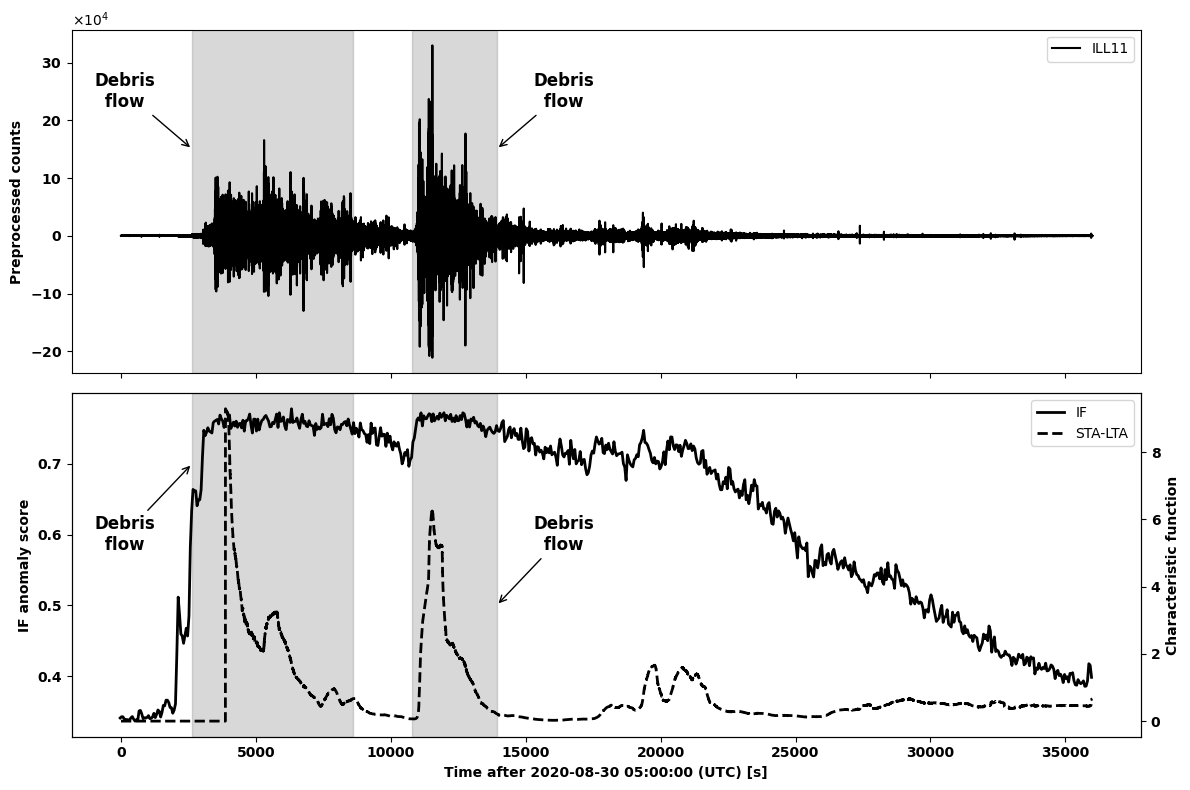

In [404]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL11")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flow ",
    xy=(flow_stop2, 150000),
    xytext=(flow_stop2 + 2500, 250000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[0].annotate(
    "Debris\n flow ",
    xy=(flow_start1, 150000),
    xytext=(flow_start1 - 2500, 250000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)


if_tr = ill11_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

axs[1].annotate(
    "Debris\n flow ",
    xy=(flow_stop2, 0.5),
    xytext=(flow_stop2 + 2500, 0.6),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[1].annotate(
    "Debris\n flow ",
    xy=(flow_start1, 0.7),
    xytext=(flow_start1 - 2500, 0.6),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

plt.tight_layout()
plt.savefig("../plots/fig09.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [405]:
# ILL12 2020-06-08
sw = 200000
lw = 4000000

ill12_paths = find_paths("XP", "ILL12", "EHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill12_paths, "2020-06-08")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill12_paths, "2020-06-07")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2020-06-08T10:00:00.000000Z")
t1 = obspy.UTCDateTime("2020-06-08T23:00:00.000000Z")

t0_gt1 = obspy.UTCDateTime("2020-06-08T14:05:00.000000Z")
t1_gt1 = obspy.UTCDateTime("2020-06-08T14:35:00.000000Z	")

t0_gt2 = obspy.UTCDateTime("2020-06-08T16:53:00.000000Z")
t1_gt2 = obspy.UTCDateTime("2020-06-08T17:40:00.000000Z	")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL12.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2020" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill12_if_st = create_if_stream(scores_df, station="ILL12", sr=0.02, network="XP")

sta_lta_tr = obspy.Trace()
sta_lta_tr.data = np.append(st_prev[0].data, st[0].data)
sta_lta_tr.stats.sampling_rate = 100
sta_lta_tr.stats.starttime = st_prev[0].stats.starttime
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

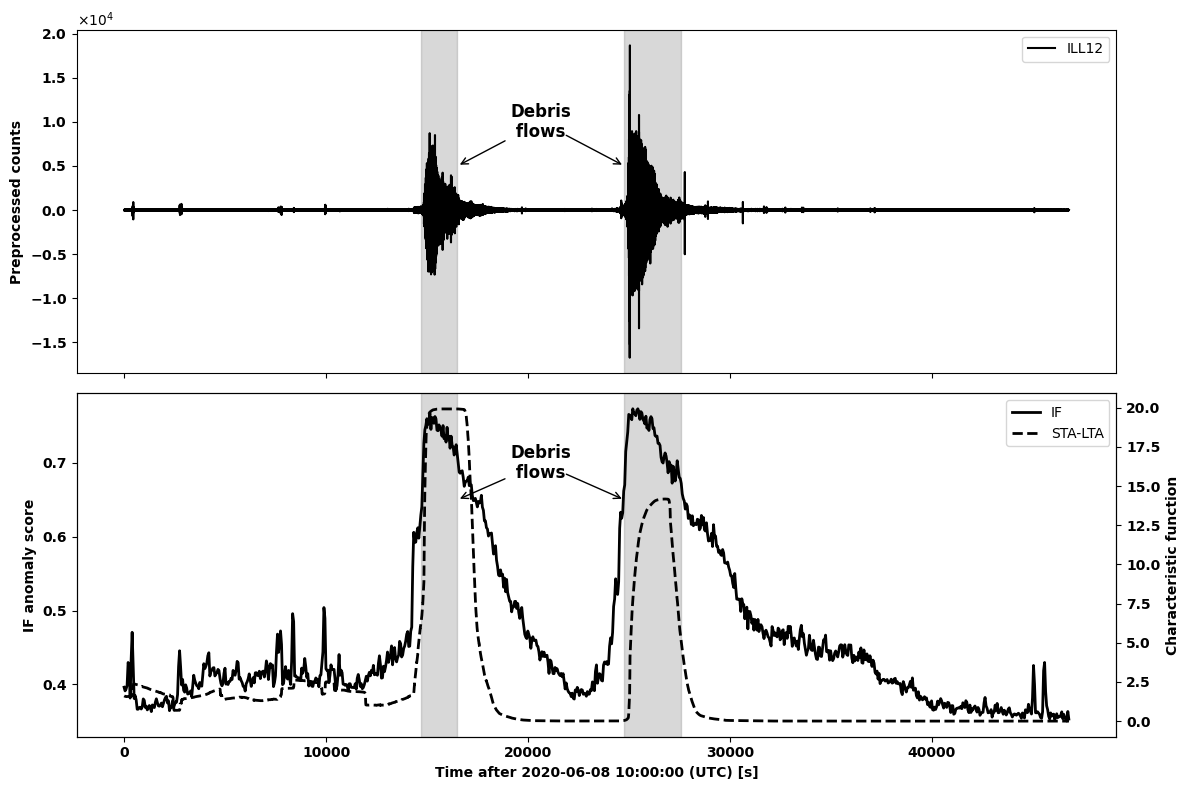

In [406]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL12")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 5000),
    xytext=(20640, 10000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[0].annotate(
    "      \n       ",
    xy=(flow_start2, 5000),
    xytext=(20640, 10000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

if_tr = ill12_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

axs[1].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 0.65),
    xytext=(20640, 0.70),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[1].annotate(
    "      \n       ",
    xy=(flow_start2, 0.65),
    xytext=(20640, 0.70),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

plt.tight_layout()
plt.savefig("../plots/fig10.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [407]:
# ILL18 2021-07-31
sw = 50000
lw = 4000000

ill18_paths = find_paths("XP", "ILL18", "EHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill18_paths, "2021-07-31")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill18_paths, "2021-07-30")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2021-07-31T18:00:00.000000Z")
t1 = obspy.UTCDateTime("2021-07-31T23:59:59.000000Z")

t0_gt1 = obspy.UTCDateTime("2021-07-31T21:08:09.000000Z")
t1_gt1 = obspy.UTCDateTime("2021-07-31T22:21:59.000000Z")

t0_gt2 = obspy.UTCDateTime("2021-07-31T23:04:34.000000Z")
t1_gt2 = obspy.UTCDateTime("2021-07-31T23:39:34.000000Z")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL18.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2021" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill18_if_st = create_if_stream(scores_df, station="ILL18", sr=0.02, network="XP")

sta_lta_tr = obspy.Trace()
sta_lta_tr.data = np.append(st_prev[0].data, st[0].data)
sta_lta_tr.stats.sampling_rate = 100
sta_lta_tr.stats.starttime = st_prev[0].stats.starttime
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

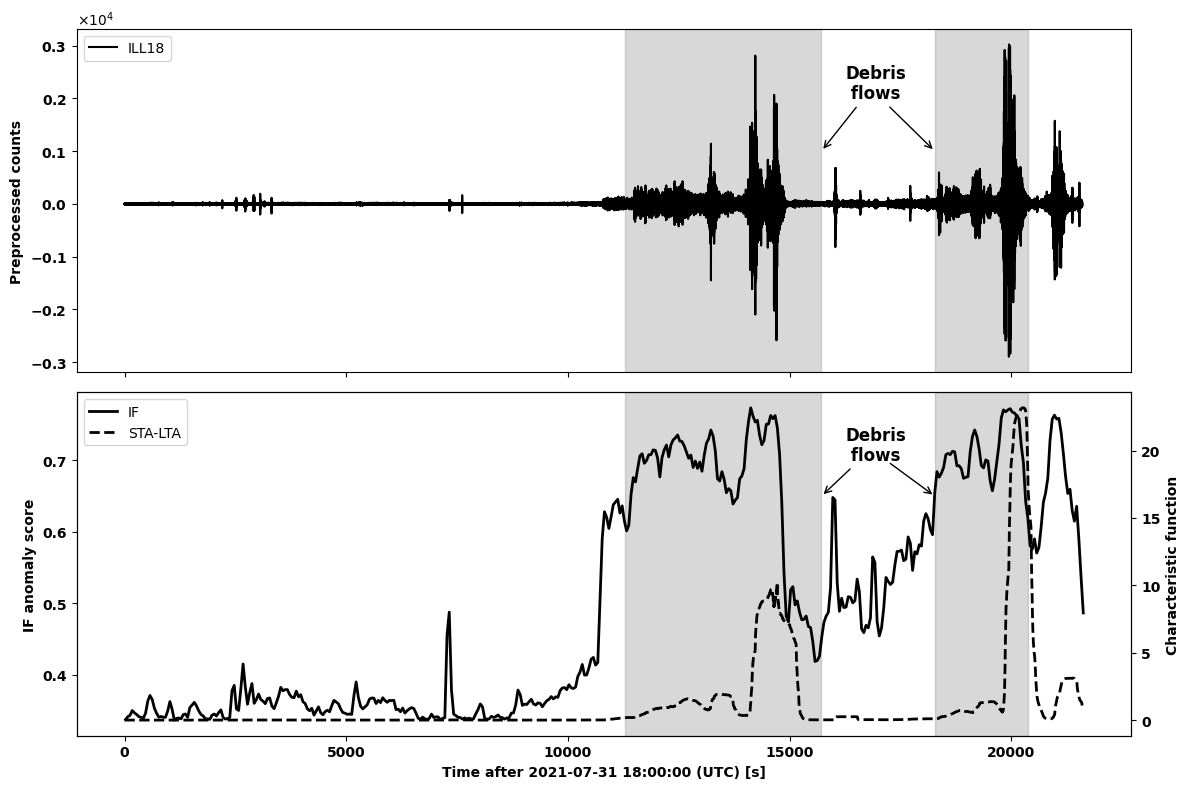

In [409]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL18")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend(loc="upper left")
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 1000),
    xytext=(16250, 2000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

axs[0].annotate(
    "      \n       ",
    xy=(flow_start2, 1000),
    xytext=(16250, 2000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

if_tr = ill18_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axs[1].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 0.65),
    xytext=(16250, 0.7),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

axs[1].annotate(
    "      \n       ",
    xy=(flow_start2, 0.65),
    xytext=(16250, 0.7),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig("../plots/fig11.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()